# Предсказание ДТП

Необходимо создать систему, которая могла бы оценить риск ДТП по выбранному маршруту движения. Под риском понимается вероятность ДТП с любым повреждением транспортного средства. Как только водитель забронировал автомобиль, сел за руль и выбрал маршрут, система должна оценить уровень риска. Если уровень риска высок, водитель увидит предупреждение и рекомендации по маршруту.
Текущая задача — понять, возможно ли предсказывать ДТП, опираясь на исторические данные одного из регионов.

<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Описание-проекта" data-toc-modified-id="Описание-проекта-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Описание проекта</a></span></li><li><span><a href="#Разведочный-анализ-SQL-таблиц" data-toc-modified-id="Разведочный-анализ-SQL-таблиц-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Разведочный анализ SQL таблиц</a></span><ul class="toc-item"><li><span><a href="#Вывод" data-toc-modified-id="Вывод-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Статистический-анализ-факторов-ДТП" data-toc-modified-id="Статистический-анализ-факторов-ДТП-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Статистический анализ факторов ДТП</a></span><ul class="toc-item"><li><span><a href="#Количество-аварий-в-зависимости-от-месяца" data-toc-modified-id="Количество-аварий-в-зависимости-от-месяца-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Количество аварий в зависимости от месяца</a></span></li><li><span><a href="#Аналитические-задачи-коллегам" data-toc-modified-id="Аналитические-задачи-коллегам-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Аналитические задачи коллегам</a></span><ul class="toc-item"><li><span><a href="#Проанализировать-влияние-типа-коробки-передач-авто-на-вероятность-ДТП" data-toc-modified-id="Проанализировать-влияние-типа-коробки-передач-авто-на-вероятность-ДТП-3.2.1"><span class="toc-item-num">3.2.1&nbsp;&nbsp;</span>Проанализировать влияние типа коробки передач авто на вероятность ДТП</a></span></li><li><span><a href="#Влияние-размера-страховки-на-вероятность-ДТП" data-toc-modified-id="Влияние-размера-страховки-на-вероятность-ДТП-3.2.2"><span class="toc-item-num">3.2.2&nbsp;&nbsp;</span>Влияние размера страховки на вероятность ДТП</a></span></li></ul></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Выгрузка-данных-и-разведочный-анализ" data-toc-modified-id="Выгрузка-данных-и-разведочный-анализ-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Выгрузка данных и разведочный анализ</a></span><ul class="toc-item"><li><span><a href="#Вывод" data-toc-modified-id="Вывод-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Исследовательский-анализ" data-toc-modified-id="Исследовательский-анализ-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Исследовательский анализ</a></span><ul class="toc-item"><li><span><a href="#Признаки" data-toc-modified-id="Признаки-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Признаки</a></span><ul class="toc-item"><li><span><a href="#Виновность-в-ДТП.-Целевой-признак" data-toc-modified-id="Виновность-в-ДТП.-Целевой-признак-5.1.1"><span class="toc-item-num">5.1.1&nbsp;&nbsp;</span>Виновность в ДТП. Целевой признак</a></span></li><li><span><a href="#Географическое-место-ДТП" data-toc-modified-id="Географическое-место-ДТП-5.1.2"><span class="toc-item-num">5.1.2&nbsp;&nbsp;</span>Географическое место ДТП</a></span></li><li><span><a href="#Погодные-условия" data-toc-modified-id="Погодные-условия-5.1.3"><span class="toc-item-num">5.1.3&nbsp;&nbsp;</span>Погодные условия</a></span></li><li><span><a href="#Дорожное-покрытие" data-toc-modified-id="Дорожное-покрытие-5.1.4"><span class="toc-item-num">5.1.4&nbsp;&nbsp;</span>Дорожное покрытие</a></span></li><li><span><a href="#День-недели" data-toc-modified-id="День-недели-5.1.5"><span class="toc-item-num">5.1.5&nbsp;&nbsp;</span>День недели</a></span></li><li><span><a href="#Час" data-toc-modified-id="Час-5.1.6"><span class="toc-item-num">5.1.6&nbsp;&nbsp;</span>Час</a></span></li><li><span><a href="#Освещение" data-toc-modified-id="Освещение-5.1.7"><span class="toc-item-num">5.1.7&nbsp;&nbsp;</span>Освещение</a></span></li><li><span><a href="#Трезвость-участника" data-toc-modified-id="Трезвость-участника-5.1.8"><span class="toc-item-num">5.1.8&nbsp;&nbsp;</span>Трезвость участника</a></span></li><li><span><a href="#Тип-автомобиля" data-toc-modified-id="Тип-автомобиля-5.1.9"><span class="toc-item-num">5.1.9&nbsp;&nbsp;</span>Тип автомобиля</a></span></li><li><span><a href="#Коробка-передач" data-toc-modified-id="Коробка-передач-5.1.10"><span class="toc-item-num">5.1.10&nbsp;&nbsp;</span>Коробка передач</a></span></li><li><span><a href="#Возраст-автомобиля" data-toc-modified-id="Возраст-автомобиля-5.1.11"><span class="toc-item-num">5.1.11&nbsp;&nbsp;</span>Возраст автомобиля</a></span></li><li><span><a href="#Разговор-по-телефону-за-рулем" data-toc-modified-id="Разговор-по-телефону-за-рулем-5.1.12"><span class="toc-item-num">5.1.12&nbsp;&nbsp;</span>Разговор по телефону за рулем</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-5.1.13"><span class="toc-item-num">5.1.13&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Корреляционный-анализ" data-toc-modified-id="Корреляционный-анализ-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Корреляционный анализ</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-5.3"><span class="toc-item-num">5.3&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Модель-для-оценки-водительского-риска" data-toc-modified-id="Модель-для-оценки-водительского-риска-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Модель для оценки водительского риска</a></span><ul class="toc-item"><li><span><a href="#Обучение-моделей" data-toc-modified-id="Обучение-моделей-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>Обучение моделей</a></span></li><li><span><a href="#Сравнение-моделей-и-выбор-лучшей" data-toc-modified-id="Сравнение-моделей-и-выбор-лучшей-6.2"><span class="toc-item-num">6.2&nbsp;&nbsp;</span>Сравнение моделей и выбор лучшей</a></span></li><li><span><a href="#Калибровка-модели" data-toc-modified-id="Калибровка-модели-6.3"><span class="toc-item-num">6.3&nbsp;&nbsp;</span>Калибровка модели</a></span></li><li><span><a href="#Анализ-лучшей-модели" data-toc-modified-id="Анализ-лучшей-модели-6.4"><span class="toc-item-num">6.4&nbsp;&nbsp;</span>Анализ лучшей модели</a></span></li><li><span><a href="#Анализ-важности-признаков" data-toc-modified-id="Анализ-важности-признаков-6.5"><span class="toc-item-num">6.5&nbsp;&nbsp;</span>Анализ важности признаков</a></span></li><li><span><a href="#Анализ-важности-факторов-ДТП" data-toc-modified-id="Анализ-важности-факторов-ДТП-6.6"><span class="toc-item-num">6.6&nbsp;&nbsp;</span>Анализ важности факторов ДТП</a></span><ul class="toc-item"><li><span><a href="#Тип-автомобиля" data-toc-modified-id="Тип-автомобиля-6.6.1"><span class="toc-item-num">6.6.1&nbsp;&nbsp;</span>Тип автомобиля</a></span></li><li><span><a href="#Возраст-автомобиля" data-toc-modified-id="Возраст-автомобиля-6.6.2"><span class="toc-item-num">6.6.2&nbsp;&nbsp;</span>Возраст автомобиля</a></span></li><li><span><a href="#Час-поездки" data-toc-modified-id="Час-поездки-6.6.3"><span class="toc-item-num">6.6.3&nbsp;&nbsp;</span>Час поездки</a></span></li></ul></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-6.7"><span class="toc-item-num">6.7&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Общий-вывод" data-toc-modified-id="Общий-вывод-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Общий вывод</a></span></li></ul></div>

## Описание проекта

**Заказчик**


Каршеринговая компания


**Входные данные**


Информация о ДТП, его участниках и пострадавших объектах


**Задача**


Создать модель предсказания ДТП на основе данных заказчика. Исследовать основные факторы ДТП. Определить дальнейшие шаги по улучшению и доработке модели, поиск дополнительных источников данных 


**Цель**


Исследование возможности предсказывания ДТП, опираясь на исторические данные одного из регионов

**Описание входных данных**





Таблицы в базе данных SQL:
- **`collisions` - Общая информация о ДТП**
    - `case_id` - Идентификационный  номер в базе данных
    - `collision_date` - Дата происшествия
    - `collision_time` - Время происшествия
    - `intersection` - Является ли место происшествие перекрёстком
    - `weather_1` - Погода
    - `collision_damage` - Серьёзность происшествия
    - `primary_col_factor` - Основной фактор аварии
    - `road_surface` - Состояние дороги (по погодным условиям)
    - `lighting` - Освещение
    - `county_city_location` - Номер географического района, где произошло ДТП
    - `county_location` - Названия географического района, где произошло ДТП
    - `direction` - Направление движения
    - `distance` - Расстояние от главной дороги (метры)
    - `location_type` - Тип дороги
    - `party_count` - Количество участников
    - `pcf_violation_category` - Категория нарушения
    - `type_of_collision` - Тип аварии
    - `motor_vehicle_invloved_with` - Дополнительные участники ДТП
    - `road_condition_1` - Состояние дорожного покрытия
    - `control_device` - Устройство управления
    
    
- **`parties` — Информация об участниках ДТП**
    - `case_id` - Идентификационный  номер в базе данных
    - `party_number` - Номер участника происшествия
    - `party_type` - Тип участника происшествия
    - `at_fault` - Виновность участника
    - `insurance_premium` - Сумма страховки (тыс. долларов)
    - `party_drug_physical` - Состояние участника: физическое или с учётом принятых лекарств
    - `party_sobriety` - Трезвость участника
    - `cellphone_in_use` - Наличие телефона в автомобиле (возможности разговаривать по громкой связи)
    
    
- **`vehicles` — Информация о пострадавших машинах**
    - `id` - Порядковый индекс
    - `case_id` - Идентификационный номер ДТП в базе
    - `vehicle_type` - Тип кузова
    - `vehicle_transmission` - Тип КПП
    - `vehicle_age` - Возраст автомобиля (в годах)

In [1]:
!pip install numba==0.57.1 -q
!pip install pingouin -q
!pip install phik -q
!pip install hyperopt -q
!pip install sqlalchemy -q
!pip install --upgrade seaborn -q
!pip install lightgbm -q
!pip install shap==0.44.0 -q

In [2]:
# данные
import random
import numpy as np
import pandas as pd
import re
import warnings
import time
from functools import partial

# графики
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter
import seaborn as sns

# МО
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder
)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_val_predict,
    RandomizedSearchCV,
    StratifiedKFold
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    precision_recall_curve,
    make_scorer,
    f1_score,
    roc_auc_score
)
from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve,
    CalibrationDisplay
)

# сторонние библиотеки
from sqlalchemy import create_engine
import pingouin as pg
import phik
import shap
from lightgbm import LGBMClassifier
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK

RANDOM_STATE=42
random.seed(42)
np.random.seed(42)
pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore")

## Разведочный анализ SQL таблиц

In [3]:
db_config = {
'user': 'praktikum_student',
'pwd': 'Sdf4$2;d-d30pp',
'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
'port': 6432,
'db': 'data-science-vehicle-db'
} 

In [4]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
                                                         db_config['user'],
                                                         db_config['pwd'],
                                                         db_config['host'],
                                                         db_config['port'],
                                                         db_config['db'],
                                                         ) 

In [5]:
engine = create_engine(connection_string) 

Посмотрим на количество таблиц и соответствует ли он оно предоставленной схеме

In [6]:
query = '''
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public';
'''

In [7]:
pd.read_sql(sql=query, con=engine.connect().connection)

,table_name
0,case_ids
1,collisions
2,parties
3,vehicles


In [8]:
query = '''
SELECT constraint_name, table_name, column_name
FROM information_schema.key_column_usage
WHERE table_name IN (SELECT table_name
                     FROM information_schema.tables
                     WHERE table_schema = 'public')
ORDER BY table_name;
'''

In [9]:
pd.read_sql(sql=query, con=engine.connect().connection)

,constraint_name,table_name,column_name
0,case_ids_pk,case_ids,case_id
1,collisions_case_ids_case_id_fk,collisions,case_id
2,parties_pk,parties,id
3,parties_case_ids_case_id_fk,parties,case_id
4,vehicles_pk,vehicles,id
5,vehicles_case_ids_case_id_fk,vehicles,case_id


In [10]:
query = '''
SELECT table_name, column_name, data_type 
FROM information_schema.columns 
WHERE table_name IN (SELECT table_name
                     FROM information_schema.tables
                     WHERE table_schema = 'public')
ORDER BY table_name, ordinal_position;
'''

In [11]:
pd.read_sql(sql=query, con=engine.connect().connection)

,table_name,column_name,data_type
0,case_ids,case_id,text
1,case_ids,db_year,text
2,collisions,case_id,text
3,collisions,county_city_location,text
4,collisions,county_location,text
5,collisions,distance,real
6,collisions,direction,text
7,collisions,intersection,integer
8,collisions,weather_1,text
9,collisions,location_type,text


### Вывод

- Количество таблиц, имена и набор данных внутри них соответсвуют схеме
- Eсть общий ключ - `case_id`, по которому можно связать все таблицы
- В таблицах `parties` и `vehicles` - уникальные ключи с одинаковым именем - `id`, порядковый номер в каждой таблице

##  Статистический анализ факторов ДТП

### Количество аварий в зависимости от месяца

Посмотрим в какие месяцы происходит наибольшее количество аварий в Калифорнии

In [12]:
query = '''
SELECT DISTINCT TO_CHAR(DATE_TRUNC('month', collision_date)::date, 'YYYY-MM') AS collision_month,
       EXTRACT(YEAR FROM collision_date)::int AS year,
       TO_CHAR(collision_date::date, 'Month') AS month,
       COUNT(case_id) OVER (PARTITION BY DATE_TRUNC('month', collision_date)) AS collisions_per_month
FROM collisions
ORDER BY collision_month;
'''

In [13]:
df_ = pd.read_sql(sql=query, con=engine.connect().connection)

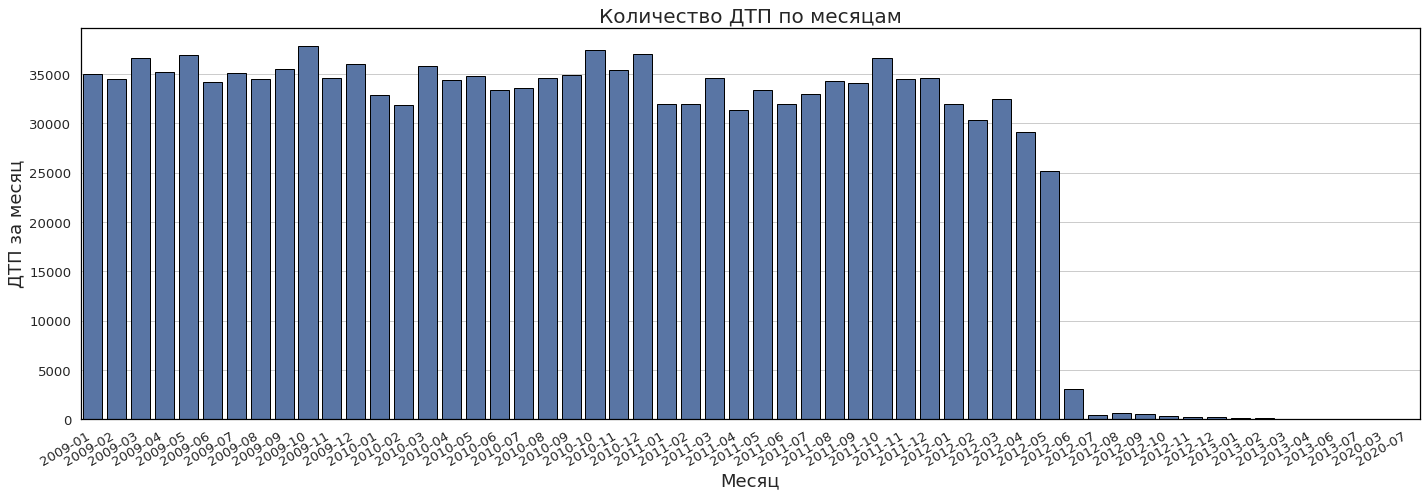

In [14]:
sns.set(font_scale=1.2)
sns.set_style('whitegrid', {'axes.edgecolor': 'black'})

fig = plt.figure(figsize=(24, 8))
sns.barplot(data=df_, 
            x='collision_month', 
            y='collisions_per_month', 
            color='b',
            edgecolor='black')
fig.autofmt_xdate()
plt.title('Количество ДТП по месяцам', fontsize=20)
plt.ylabel('ДТП за месяц', fontsize=18)
plt.xlabel('Месяц', fontsize=18);

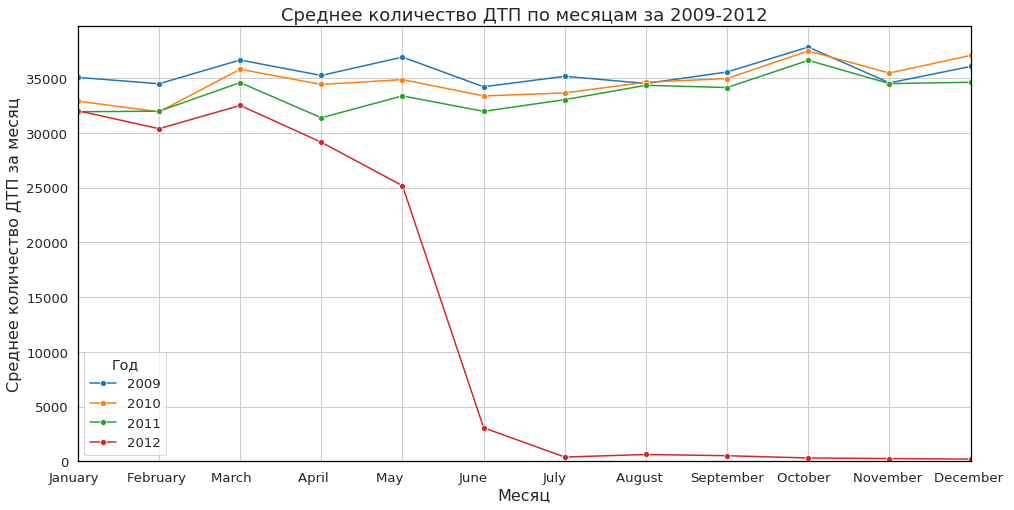

In [15]:
fig = plt.figure(figsize=(16, 8))
sns.lineplot(data=df_[df_['year']<2013], 
             x='month', 
             y='collisions_per_month', 
             hue='year',
             marker='o',
             palette='tab10')
plt.margins(x=0)
plt.ylim(bottom=-0.05)
plt.legend(title='Год')
plt.title('Среднее количество ДТП по месяцам за 2009-2012', fontsize=18)
plt.ylabel('Среднее количество ДТП за месяц', fontsize=16)
plt.xlabel('Месяц', fontsize=16);

Видим, что после апреля 2012 года начинается сильный провал в данных, может быть перешли на другую систему или изменился сбор данных. Ограничим выборку до апрелем 2012, чтобы адекватно усреднить данные. А пока посмотрим на средние данные за полные года - 2009-2011

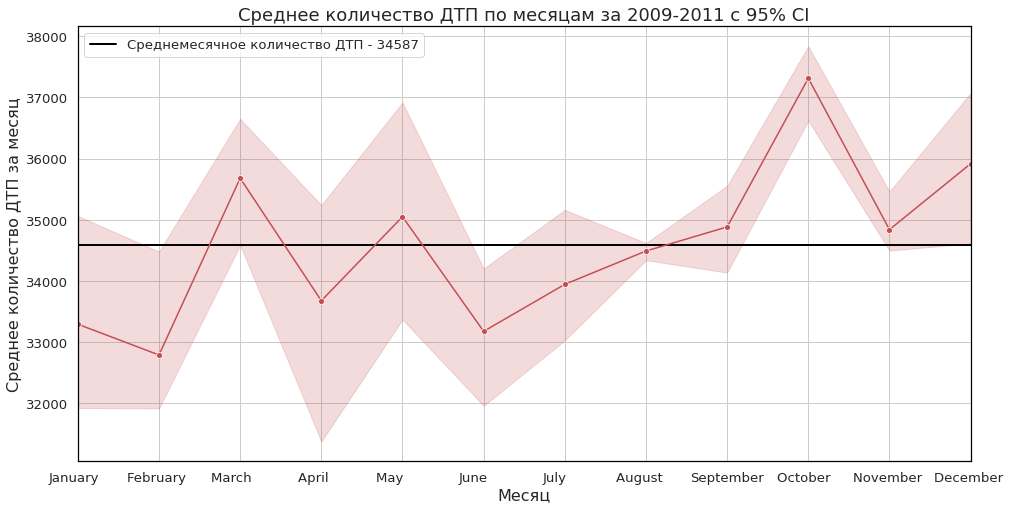

In [16]:
fig = plt.figure(figsize=(16, 8))
sns.lineplot(data=df_[df_['year']<2012], 
             x='month', 
             y='collisions_per_month', 
             color='r', 
             marker='o')
plt.axhline(y=df_.query('year<2012')['collisions_per_month'].mean(), 
            color='black', 
            lw=2,
            label=f'Среднемесячное количество ДТП - '
                  f'{round(df_.query("year<2012")["collisions_per_month"].mean())}',
            zorder=1)
plt.legend(loc='upper left')
plt.margins(x=0)
plt.title('Среднее количество ДТП по месяцам за 2009-2011 с 95% CI', fontsize=18)
plt.ylabel('Среднее количество ДТП за месяц', fontsize=16)
plt.xlabel('Месяц', fontsize=16);

Наблюдается некоторая сезонность ДТП в течение года. С начала лета и до октября идет рост до максимума, после чего сильный спад в январе на праздники и затем возрастает до средних значений за год - 34587 ДТП и держится так всреднем до начала осени. С 95% CI октябрь, ноябрь и декабрь находятся выше среднемесячных значений по ДТП

In [17]:
query = '''
WITH cols AS (
 SELECT DISTINCT DATE_TRUNC('month', collision_date)::date AS collision_month,
        COUNT(case_id) OVER (PARTITION BY DATE_TRUNC('month', collision_date)) AS collisions_per_month
 FROM collisions
 WHERE collision_date < '2012-05-01'
 )
SELECT DISTINCT TO_CHAR(collision_month, 'Month') AS month, 
       AVG(collisions_per_month) OVER (PARTITION BY EXTRACT(MONTH FROM collision_month)) AS mean_cols_per_month,
       STDDEV(collisions_per_month) OVER (PARTITION BY EXTRACT(MONTH FROM collision_month)) AS std_per_month
FROM cols
ORDER BY mean_cols_per_month DESC;
'''

In [18]:
df_ = pd.read_sql(sql=query, con=engine.connect().connection)

,month,mean_cols_per_month,std_per_month
0,October,37311,625.853817
1,December,35915,1233.906398
2,May,35049,1780.407070
3,March,34883,1801.726302
4,September,34883,711.890441
5,November,34839,538.844133
6,August,34489,141.460242
7,July,33945,1097.203719
8,June,33177,1132.022526
9,January,32975,1457.724711


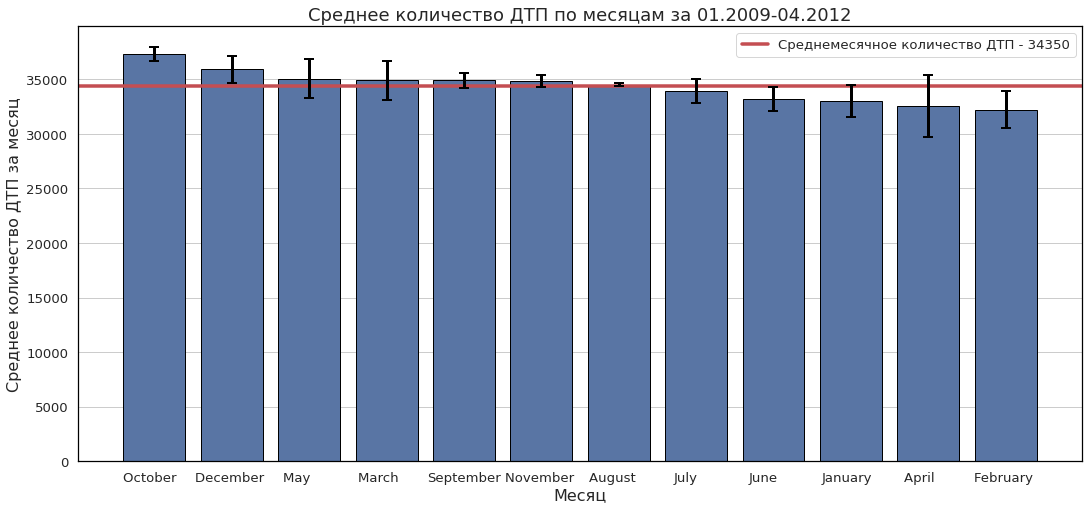

In [19]:
sns.set(font_scale=1.2)
sns.set_style('whitegrid', {'axes.edgecolor': 'black'})

fig = plt.figure(figsize=(18,8))
sns.barplot(data=df_, 
            x='month', 
            y='mean_cols_per_month', 
            color='b',
            edgecolor='black')
plt.errorbar(x=df_['month'], 
             y=df_['mean_cols_per_month'],
             yerr=df_['std_per_month'], 
             fmt='none', 
             c='black',
             elinewidth=3,
             capsize=5,
             markeredgewidth=2)
plt.axhline(y=df_['mean_cols_per_month'].mean(), 
            color='r', 
            lw=3.5,
            label=f'Среднемесячное количество ДТП - {round(df_["mean_cols_per_month"].mean())}',
            zorder=1)
plt.legend()
plt.title('Среднее количество ДТП по месяцам за 01.2009-04.2012', fontsize=18)
plt.ylabel('Среднее количество ДТП за месяц', fontsize=16)
plt.xlabel('Месяц', fontsize=16);
df_['mean_cols_per_month'] = df_['mean_cols_per_month'].astype(int)
df_

- Больше всего ДТП за период 2009-середина 2012 года в среднем происходило в 
    - Октябре - 37311
    - Декабре - 35915
    - Мае - 35049


- В 95% CI выше среднемесячных значений лежат 3 последних месяца года - октябрь, ноябрь и декабрь
    
    
- Меньше всего ДТП за тот же период в среднем происходило в
    - Феврале - 32187
    - Апреле - 32543
    - Январе - 32975
    

- В первую очередь это связано со сменой сезонов
    - В октябре идет усиленная смена погодного сезона
    - В декабре зима, дожди в Калифорнии, на севере штата может подмораживать
    - В мае заметно теплеет, проблемы с дорожным полотном после зимнего сезона, совершается больше дальних поездок
    
    
- Индивидуальные особенности
    - В феврале - 28 дней, на 2-3 дня меньше, чем в другие месяцы
    - В апреле - улучшаются погодные условия после зимнего периода
    - В январе праздники, когда количество поездок меньше, чем обычно

### Аналитические задачи коллегам

1. Выяснить в какие часы дня ДТП происходят чаще
2. Исследовать какие нарушения ПДД чаще всего являются причиной ДТП
3. Определить влияние проблем с состоянием дороги на частоту ДТП
4. Выяснить на каких участках дороги происходят ДТП с количеством машин больше 2
5. Проанализировать влияние типа коробки передач авто на вероятность ДТП
6. Исследовать влияние типа автомобиля на вероятность ДТП
7. Рассмотреть погоду как фактор ДТП
8. Определить влияние трезвости и физического состояния водителя на вероятность ДТП
9. Исследовать вопрос влияния размера страховки на вероятность ДТП и предложить варианты конвертации в условие для водителей в системе каршеринга

#### Проанализировать влияние типа коробки передач авто на вероятность ДТП

Рассмотрим задачу 5


- Выгрузить данные из SQL базы, учитывая сложную связь `collisions`, `parties` и `vehicles`, а так же, что в одном ДТП может быть больше 2 участников
- Построить диаграмму по относительному количеству ДТП с АКПП и МКПП, дополнительно сделать разрез в контексте виновников и пострадавших
- Сделать вывод. Предложить идеи для компании в контексте задачи

In [20]:
query = '''
WITH raw AS (
    SELECT DISTINCT v.vehicle_transmission,
           p.at_fault, 
           COUNT(c.case_id) OVER (PARTITION BY v.vehicle_transmission, p.at_fault) AS acc_count
    FROM collisions c
    LEFT JOIN parties p ON p.case_id=c.case_id
    LEFT JOIN vehicles v ON p.case_id=v.case_id AND p.party_number=v.party_number
    WHERE v.vehicle_transmission IS NOT NULL
    ORDER BY v.vehicle_transmission, p.at_fault
)
SELECT vehicle_transmission,
       at_fault,
       acc_count,
       ROUND(100 * acc_count / t.total, 2) AS acc_abs_percent,
       ROUND(100 * acc_count / SUM(acc_count) OVER (PARTITION BY at_fault), 2) AS acc_rel_percent
FROM raw
CROSS JOIN (SELECT SUM(acc_count) AS total FROM raw) t
'''

In [21]:
df_ = pd.read_sql(sql=query, con=engine.connect().connection)

,vehicle_transmission,at_fault,acc_count,acc_abs_percent,acc_rel_percent
0,auto,0,300384,30.11,53.82
1,manual,0,257778,25.84,46.18
2,auto,1,201859,20.23,45.94
3,manual,1,237554,23.81,54.06


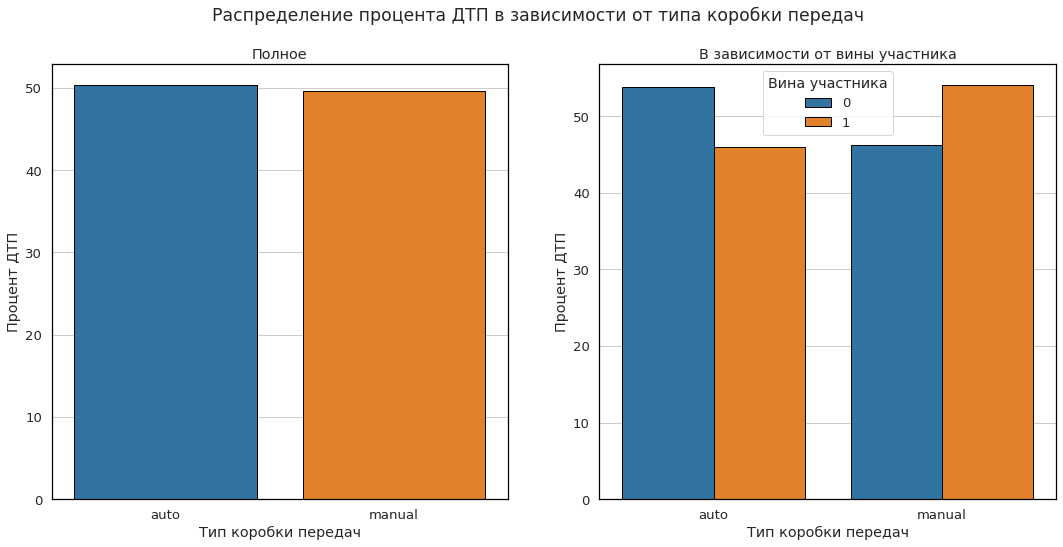

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

ax1 = sns.barplot(data=df_,
            x='vehicle_transmission',
            y='acc_abs_percent',
            estimator='sum',
            errorbar=None,
            edgecolor='black',
            palette='tab10',
            ax=ax[0]
           )

ax2 = sns.barplot(data=df_,
                  x='vehicle_transmission',
                  y='acc_rel_percent',
                  hue='at_fault',
                  edgecolor='black',
                  palette='tab10',
                  ax=ax[1]
                 )
fig.suptitle('Распределение процента ДТП в зависимости от типа коробки передач')
ax[0].set_title('Полное')
ax[0].set_xlabel('Тип коробки передач')
ax[0].set_ylabel('Процент ДТП')
ax[1].set_title('В зависимости от вины участника')
ax[1].set_xlabel('Тип коробки передач')
ax[1].set_ylabel('Процент ДТП')
ax[1].legend(title='Вина участника')
df_

- В общем случае ДТП не зависят от типа коробки передач у всех участников
- Среди виновников ДТП чаще происходит с МКПП, чем с АКПП примерно на 10 %
- Среди пострадавших ДТП - наоборот, чаще с АКПП примерно на 8 %
- Можно предложить ограничение по водительскому удостоверению клиента на управление МКПП, либо делать дополнительное предупреждение, либо искусственно ограничивать выбор авто в зависимости от стажа

#### Влияние размера страховки на вероятность ДТП

Рассмотрим задачу 9


- Выгрузить данные из SQL базы, учитывая связь `collisions`, `parties`, а так же, что в одном ДТП может быть больше 2 участников
- Построить распределение количества ДТП в зависимости от размера страховки, учесть наличие пропусков, дополнительно оценить распределение в разрезе вины участника
- Сделать вывод. Предложить идеи для компании в контексте задачи

In [23]:
query = '''
WITH raw AS (
    SELECT DISTINCT ROUND(p.insurance_premium/10) as insurance_premium,
           p.at_fault,
           COUNT(c.case_id) OVER (PARTITION BY ROUND(p.insurance_premium/10), p.at_fault) AS acc_count
    FROM collisions c
    LEFT JOIN parties p ON p.case_id=c.case_id
)
SELECT insurance_premium,
       at_fault,
       acc_count,
       ROUND(100 * acc_count / t.total, 2) AS acc_abs_percent,
       ROUND(100 * acc_count / SUM(acc_count) OVER (PARTITION BY at_fault), 2) AS acc_rel_percent
FROM raw
CROSS JOIN (SELECT SUM(acc_count) AS total FROM raw) t
ORDER BY insurance_premium, at_fault
'''

In [24]:
df_ = pd.read_sql(sql=query, con=engine.connect().connection).fillna(-1)

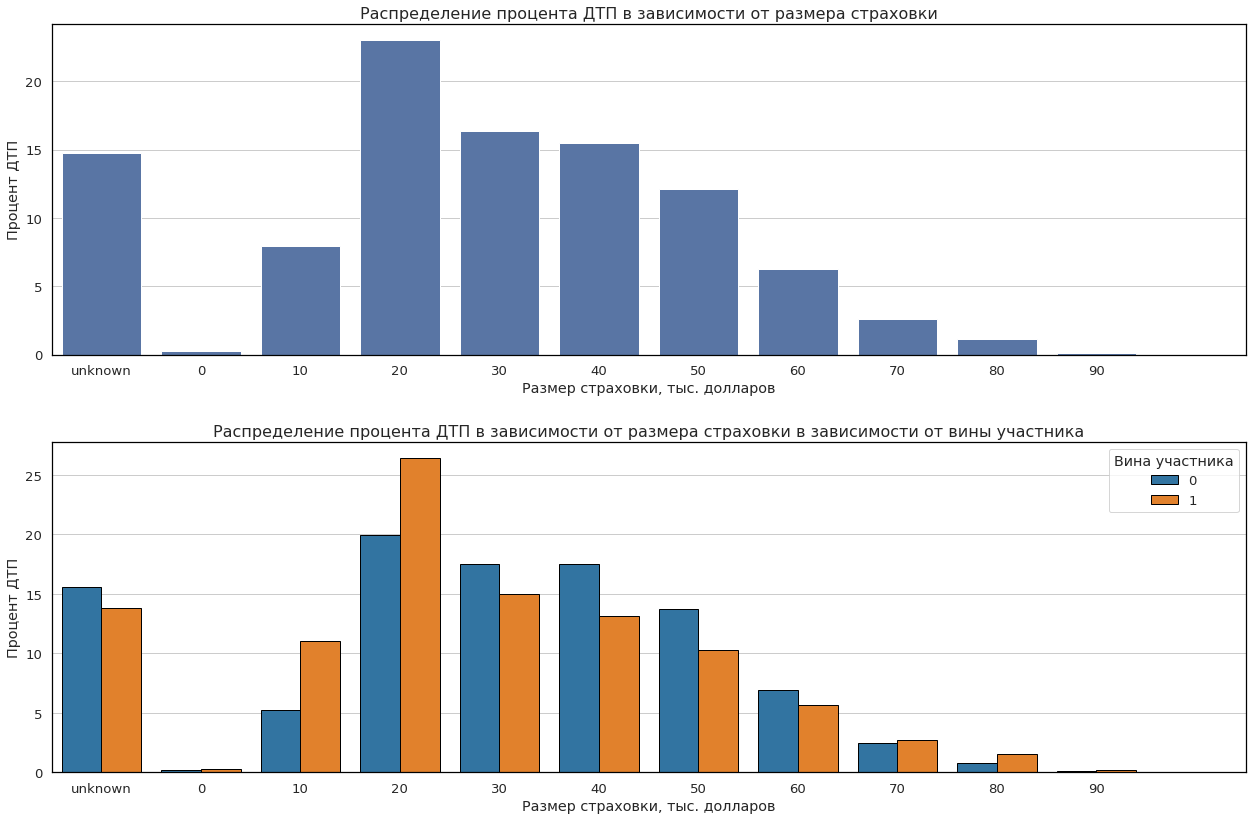

In [25]:
fig, ax = plt.subplots(2, 1, figsize=(18, 12))

ax1 = sns.barplot(data=df_,
                  x='insurance_premium',
                  y='acc_abs_percent',
                  estimator='sum',
                  errorbar=None,
                  ax=ax[0]
                  )

ax2 = sns.barplot(data=df_,
                  x='insurance_premium',
                  y='acc_rel_percent',
                  hue='at_fault',
                  edgecolor='black',
                  palette='tab10',
                  ax=ax[1]
                 )
ax[0].set_title('Распределение процента ДТП в зависимости от размера страховки', fontsize=16)
ax[0].set_xlabel('Размер страховки, тыс. долларов')
ax[0].set_ylabel('Процент ДТП')
ax[0].set_xticklabels(['unknown'] + list(map(str, range(0, 100, 10))))
ax[1].set_title('Распределение процента ДТП в зависимости от размера страховки' 
                ' в зависимости от вины участника', fontsize=16)
ax[1].set_xlabel('Размер страховки, тыс. долларов')
ax[1].set_ylabel('Процент ДТП')
ax[1].legend(title='Вина участника')
ax[1].set_xticklabels(['unknown'] + list(map(str, range(0, 100, 10))))
fig.tight_layout(pad=2.0)

- В общем случае больше всего ДТП происходит при размере страховки от 20 до 30 тыс. долларов и далее плавно спадает к 90 тыс. долларов, а число ДТП с неизвестным размером страховки на уровне 30-40 тыс. долларов
- Почти все водители имеют страховку
- Среди виновников ДТП чаще при размере страховки менее 30 тыс. долларов (10-20)
- Среди пострадавших в ДТП - страховка более 30 тыс. долларов
- Среди участников с неизвестной суммой страховки результаты примерно равные, если принимать во внимание ДТП с более 2 участников
- Можно предложить обязательную страховку для аккаунта, цена которой варьируется от опыта, чем больше стаж - тем ниже страховка, так получится отсечь небольшую часть неответственных или молодых водителей, у которых риск ДТП выше

### Вывод

- Предложены 9 задач для коллег. Решения некоторых из них:


1. Количество аварий в зависимости от месяца
    - Больше всего ДТП за период 2009-середина 2012 года в среднем происходило в 
        - Октябре - 37311
        - Декабре - 35915
        - Мае - 35049
        - В 95% CI выше среднемесячных значений лежат 3 последних месяца года - октябрь, ноябрь и декабрь   
    - Меньше всего ДТП за тот же период в среднем происходило в
        - Феврале - 32187
        - Апреле - 32543
        - Январе - 32975
    - В первую очередь это связано со сменой сезонов 
    - Индивидуальные особенности, вроде короткого месяца (февраль) или праздников
    - **Предложение**
        - Можно предложить делать дополнительное предупреждение в такие дни в приложении или инф.окно в главном экране


2. Влияние типа коробки передач авто на вероятность ДТП
    - В общем случае ДТП не зависят от типа коробки передач у всех участников
    - Среди виновников ДТП чаще происходит с МКПП, чем с АКПП примерно на 10 %
    - Среди пострадавших ДТП - наоборот, чаще с АКПП примерно на 8 %
    - **Предложение**
        - Можно предложить ограничение по водительскому удостоверению клиента на управление МКПП, либо делать дополнительное предупреждение, либо искусственно ограничивать выбор авто в зависимости от стажа


3. Влияние размера страховки на вероятность ДТП
    - В общем случае больше всего ДТП происходит при размере страховки от 20 до 30 тыс. долларов - около 25 % и далее плавно спадает к 90 тыс. долларов
    - Среди виновников ДТП чаще при размере страховки менее 30 тыс. долларов (10-20)
    - **Предложение**
        - Можно предложить обязательную страховку для аккаунта, цена которой варьируется от опыта, чем больше стаж - тем ниже страховка, так получится отсечь небольшую часть неответственных или молодых водителей, у которых риск ДТП выше

## Выгрузка данных и разведочный анализ

Проблема с задачей и данными, так как по всей видимости данные от дорожной полиции, а не каршеринговой компании, поэтому не виновники в ДТП будут иметь похожие значения по географии или погоде, хотя по факту намного меньше ДТП в ясную погоду, например. Кроме того, будет смещение в сторону меньшних виновников ДТП в случае с большим колчеством пострадавших машин, например на перекрестке, можно попробовать ограничить число участников до двух

В запросе нам надо отобрать признаки, которые будут важны для оценки вероятности ДТП при посадке водителя в автомобиль, чтобы удовлетворять причинно-следственной связи, кроме того, наш заказчик - каршеринговая компания, поэтому априорно считаем, что состояние автомобиля лежит на компании до посадки клиента в автомобиль. Таким образом первично отберем следующие признаки:


- **`case_id` и `party_number`** для определения уникальности записи, потом просто уберем их
- **`county_location`** - примерно географическое положение поездки, округ
- **`county_city_location`** - в крупных городах больше вероятность ДТП
- **`weather_1`** - влияние погодных условий определенно может повысить вероятность ДТП, например дождь
- **`road_surface`** - погодное состояние дорожного покрытия опять же связано с погодой и влияет на управляемость ТС
- **`lighting`** - освещенность помогает оценивать ситуацию на дороге, по пути маршрута, если он окажет влияние, то надо будет что-то делать с фарами ТС
- **`collision_date`** - день недели может влиять на загруженность дорог и вероятность ДТП
- **`collision_time`** - время дня так же влияет на загружженость дорог, освещенность, состояние водителя, ночью не все так же активны, как и днем
- **`party_sobriety`** - трезвость водителя - один из основных факторов ДТП, **в моделировании использовать его не будем**, но выгрузим для EDA и корреляционного анализа
- **`at_fault`** - целевой признак
- **`cellphone_in_use`** - наличие встроенной громкой связи, если признак правильно описан, позволяет снизить вероятность использования телефона во время вождения
- **`vehicle_type`** - тип машины может влиять на аггресивность вождения и стиль, например Nissan Armada ощущается как катер, а водитель мог иметь до этого дело только с седанами, габариты
- **`vehicle_transmission`** - МКПП может стать причиной ДТП, если водитель до этого всегда ездил только с АКПП
- **`vehicle_age`** - возраст автомобиля может быть интерпретирован как износ деталей авто, например тормозных колодок

In [26]:
def analyze(data):
    
    data.info()
    display(data.head())
    
    stats = {'values' : [
                         'Unique, count',
                         'Unique, %',
                         'Missing, count',
                         'Missing, %'
                        ]}
    for col in data:
        stats[col] = [
                      data[col].nunique(),
                      round(100 * data[col].nunique() / data.shape[0], 2),
                      data[col].isnull().sum(),
                      round(100 * data[col].isnull().sum() / data.shape[0], 2)
                     ]
    stats = pd.DataFrame(stats).set_index('values').T
    display(stats.sort_values('Missing, %', ascending=False))
    display(data.describe())
    
    print(f'\nПолных явных дубликатов - {data.duplicated().sum()}')
    print('Уникальные значения')
    for col in df:
        if df[col].nunique() < 10:
            print(f'Признак {col}, значения:', df[col].unique())

Выгрузим данные по условию заказчика
- За 2012 год, хотя мы видели, что это не самый лучший год для наблюдений
- Участиник ДТП машины, тут понятно, виновник и постарадавший для обучения модели
- Степень повреждений - царапина, для виновников будем использовать её, как того требует заказчик, а вот для пострадавших не будем использовать это ограничение, чтобы увеличить выборку с целевым признаком `0`

In [27]:
query = '''
WITH c AS (
           SELECT *
           FROM collisions
           WHERE EXTRACT(YEAR FROM collision_date)=2012 AND
           LOWER(collision_damage) NOT LIKE ('%scratch%')
           )
SELECT c.case_id,
       c.county_city_location, 
       c.county_location,
       c.weather_1,
       c.road_surface,
       c.lighting,
       TO_CHAR(c.collision_date, 'Day') AS weekday,
       EXTRACT(HOUR FROM c.collision_time) AS hour,
       p.party_number,
       p.party_sobriety,
       p.at_fault,
       p.cellphone_in_use,
       v.vehicle_type,
       v.vehicle_transmission,
       v.vehicle_age
FROM c
JOIN parties p ON p.case_id=c.case_id
JOIN vehicles v ON p.case_id=v.case_id AND p.party_number=v.party_number
WHERE LOWER(p.party_type) LIKE ('%car%')
ORDER BY c.case_id, p.party_number;
'''

In [28]:
df = pd.read_sql(sql=query, con=engine.connect().connection, coerce_float = False)

In [29]:
analyze(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56248 entries, 0 to 56247
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   case_id               56248 non-null  object 
 1   county_city_location  56248 non-null  object 
 2   county_location       56248 non-null  object 
 3   weather_1             56080 non-null  object 
 4   road_surface          55900 non-null  object 
 5   lighting              56094 non-null  object 
 6   weekday               56248 non-null  object 
 7   hour                  56160 non-null  object 
 8   party_number          56248 non-null  int64  
 9   party_sobriety        55376 non-null  object 
 10  at_fault              56248 non-null  int64  
 11  cellphone_in_use      51777 non-null  float64
 12  vehicle_type          56248 non-null  object 
 13  vehicle_transmission  55389 non-null  object 
 14  vehicle_age           54554 non-null  float64
dtypes: float64(2), int6

,case_id,county_city_location,county_location,weather_1,road_surface,lighting,weekday,hour,party_number,party_sobriety,at_fault,cellphone_in_use,vehicle_type,vehicle_transmission,vehicle_age
0,5125160,3712,san diego,cloudy,dry,daylight,Friday,7,2,had not been drinking,0,0.0,sedan,auto,2.0
1,5173738,3404,sacramento,clear,dry,daylight,Monday,12,2,had not been drinking,0,0.0,sedan,auto,5.0
2,5269486,3400,sacramento,clear,dry,daylight,Tuesday,16,2,had not been drinking,0,0.0,sedan,auto,1.0
3,5319820,3607,san bernardino,clear,dry,dark with street lights,Wednesday,19,2,had not been drinking,0,0.0,sedan,auto,4.0
4,5329109,3400,sacramento,clear,dry,daylight,Saturday,13,1,had not been drinking,0,0.0,coupe,auto,6.0


values,"Unique, count","Unique, %","Missing, count","Missing, %"
cellphone_in_use,2.0,0.00,4471.0,7.95
vehicle_age,20.0,0.04,1694.0,3.01
party_sobriety,6.0,0.01,872.0,1.55
vehicle_transmission,2.0,0.00,859.0,1.53
road_surface,4.0,0.01,348.0,0.62
weather_1,7.0,0.01,168.0,0.30
lighting,5.0,0.01,154.0,0.27
hour,24.0,0.04,88.0,0.16
case_id,44832.0,79.70,0.0,0.00
county_city_location,496.0,0.88,0.0,0.00


,party_number,at_fault,cellphone_in_use,vehicle_age
count,56248.000000,56248.000000,51777.000000,54554.000000
mean,1.527432,0.504427,0.020357,4.856472
std,0.662507,0.499985,0.141218,3.234503
min,1.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,3.000000
50%,1.000000,1.000000,0.000000,4.000000
75%,2.000000,1.000000,0.000000,7.000000
max,9.000000,1.000000,1.000000,161.000000



Полных явных дубликатов - 0
Уникальные значения
Признак weather_1, значения: ['cloudy' 'clear' 'fog' 'other' 'raining' None 'wind' 'snowing']
Признак road_surface, значения: ['dry' 'wet' 'snowy' None 'slippery']
Признак lighting, значения: ['daylight' 'dark with street lights' 'dusk or dawn'
 'dark with no street lights' None
 'dark with street lights not functioning']
Признак weekday, значения: ['Friday   ' 'Monday   ' 'Tuesday  ' 'Wednesday' 'Saturday ' 'Thursday '
 'Sunday   ']
Признак party_number, значения: [2 1 3 4 5 6 8 7 9]
Признак party_sobriety, значения: ['had not been drinking' 'impairment unknown'
 'had been drinking, under influence'
 'had been drinking, impairment unknown' None
 'had been drinking, not under influence' 'not applicable']
Признак at_fault, значения: [0 1]
Признак cellphone_in_use, значения: [ 0. nan  1.]
Признак vehicle_type, значения: ['sedan' 'coupe' 'other']
Признак vehicle_transmission, значения: ['auto' 'manual' None]


### Вывод

- Всего 56248 записей
- Как видим, полных дубликатов нет, значит можно убрать `case_id` и `party_number`
- Пропуски
    - `vehicle_transmission` - заменим на `Unknown` или оставим `None` в зависимости от модели
    - `cellphone_in_use` - заменим на `Unknown` или оставим `None` в зависимости от модели
    - `road_surface` - заменим на `Unknown` или оставим `None` в зависимости от модели
    - `hour` - выбросим
    - `lighting` - выбросим
    - `weather_1` - заменим на `other` в соответсвии с описанием таблиц
    - `vehicle_age` - заполним пропуски `-1`

## Исследовательский анализ

In [30]:
df.drop(['case_id','party_number'], axis=1, inplace=True) 

In [31]:
sns.set(font_scale=1.2)
sns.set_style('whitegrid', {'axes.edgecolor': 'black'})

# Определим функцию для графического и описательного анализа столбцов
def describe_column(data, hue=None, alpha=1, ax=None, explode=None):

    # Условие на тип диаграммы не категориальной без сравнения:

    if (data.dtype != object) & (hue is None):

        fig = plt.figure(figsize=(20,6))
        # проверка на непрерывность
        if data.nunique() > 26:

            # Настройки сетки графика
            gs = gridspec.GridSpec(2, 2, height_ratios=[5, 1])
            gs.update(hspace=0)
            ax_hist = plt.subplot(gs[0, 0])
            ax_box = plt.subplot(gs[1, 0])
            ax_qq = plt.subplot(gs[:, 1])

            # Boxplot и гистограмма
            sns.boxplot(x=data, ax=ax_box)
            sns.histplot(x=data,
                         bins='sturges',
                         alpha=alpha,
                         edgecolor='black',
                         ax=ax_hist,
                         stat='probability')
            plt.subplots_adjust(hspace=0)

        # дискретный
        else:
            # Настройки сетки графика
            gs = gridspec.GridSpec(1, 2)
            ax_hist = plt.subplot(gs[0])
            ax_qq = plt.subplot(gs[1])

            sns.countplot(x=data,
                alpha=alpha,
                edgecolor='black',
                stat = 'probability',
                ax=ax_hist)

        ax_hist.set_ylabel('Частота', size=14)
        ax_hist.set_title(f'Распределение признака {data.name}', size=14)

        # QQ-plot
        pg.qqplot(data, ax=ax_qq, square=False)
        ax_qq.set_title(f'Нормальный график Q-Q признака {data.name}', size=14)
        ax_qq.set_xlabel('Нормальные квантили', size=14)
        ax_qq.set_ylabel('Признаковые квантили', size=14)

        plt.show()

        # Описательная статистика
        display(pd.DataFrame(data.describe()).T)

    # Условие на тип диаграммы не категориальной со сравнением по признаку:
    elif hue is not None:
        fig = plt.figure(figsize=(12,6))

        if data.nunique() < 12:
            discr = True
            shr = 0.8
            multi = 'dodge'
        else:
            discr = None
            shr = 1
            multi = 'layer'

        sns.histplot(x=data,
                     alpha=alpha,
                     hue=hue,
                     edgecolor='black',
                     common_norm=False,
                     stat='probability',
                     bins='sturges',
                     discrete=discr,
                     shrink=shr,
                     multiple=multi)
        plt.title(f'Распределение признака {data.name} в зависимости от {hue.name}',
                  size=14)
        if data.dtype == object:
            plt.xticks(rotation=30, ha='right')
        plt.show()

    # Условие на категориальный тип диаграммы
    else:
        if ax is not None:
            data.value_counts().plot(kind='pie',
                                     autopct=make_autopct(data.value_counts()),
                                     fontsize=12, ax=ax)
        else:
            data.value_counts().plot(kind='pie', explode=explode,
                                     autopct=make_autopct(data.value_counts()),
                                     fontsize=12, figsize=(6, 6))
        plt.title(f'Распределение признака {data.name}', fontsize=12)
        plt.ylabel('')

# создадим дополнтильную функцию для вывода количества элементов в блоке для графика pie
# возвращает подпись элемента в % и число
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{p:.2f}%\n({v:d})'.format(p=pct,v=val)
    return my_autopct

### Признаки

#### Виновность в ДТП. Целевой признак

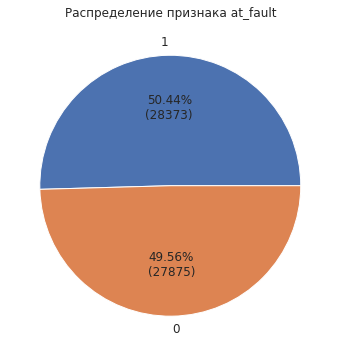

In [32]:
describe_column(df['at_fault'].astype(str))

Классов в целевом признаке поровну, отлично
- 50.4 % - виновники ДТП
- 49.6 % - пострадавшие

#### Географическое место ДТП

In [33]:
df['county_location'].nunique()

58

In [34]:
pd.DataFrame(df['county_location'].value_counts(normalize=True)*100).head(15)

,proportion
county_location,
los angeles,28.865026
orange,9.536339
san diego,6.649125
san bernardino,6.487342
riverside,5.889987
sacramento,3.884583
alameda,3.335230
santa clara,3.280117
ventura,2.606315


Слишком много уникальных значений с маленьким процентом от общего числа. Оставим топ-15, остальные уберем в `other`

In [35]:
main_loc = df['county_location'].value_counts().nlargest(14).index
df['county_location'] = df['county_location'].apply(lambda x: x if x in main_loc else 'other')

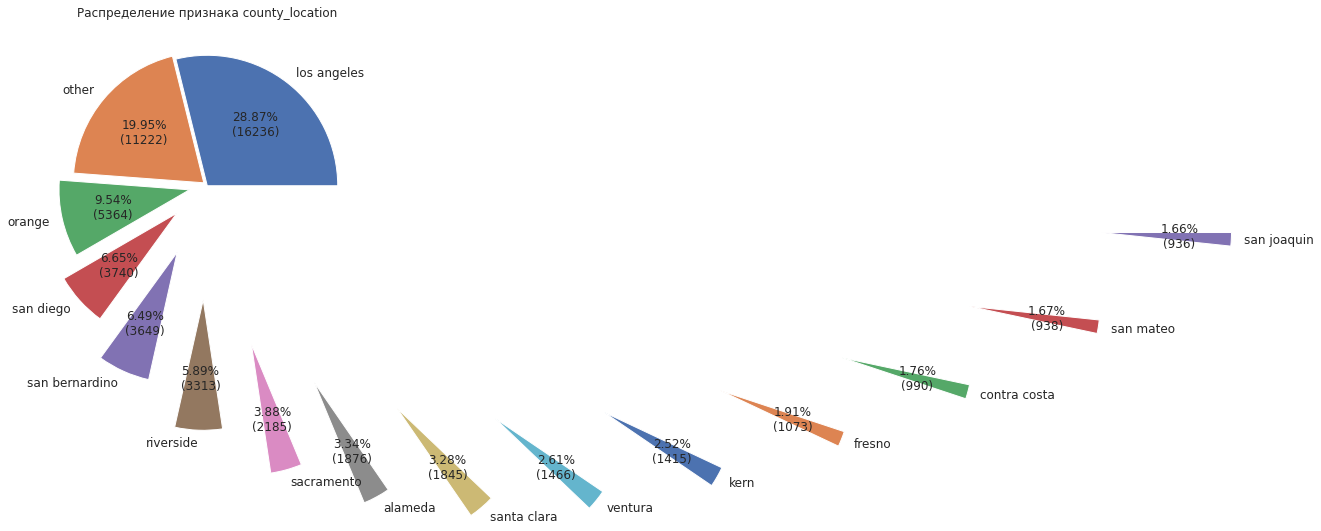

In [36]:
describe_column(df['county_location'], 
                explode=[0.035*i**2 for i in range(df['county_location'].nunique())])

Отлично, получилось 15 округов

Посмотрим на 513 городов внутри округов

In [37]:
df.query('county_location=="los angeles"')['county_city_location'].value_counts().head(20)

county_city_location
1942    6931
1900    2234
1941     458
1953     357
1985     306
1949     291
1920     289
1955     277
1992     243
1925     232
1990     203
1950     200
1912     198
1965     194
1975     184
1919     167
1964     166
1906     153
1914     151
1922     147
Name: count, dtype: int64

Первые две цифры в номере города - округ, вторые две - город. В LA происходит около 11 % всех ДТП

In [38]:
df['county_city_location'].value_counts().head(50).sum()

31884

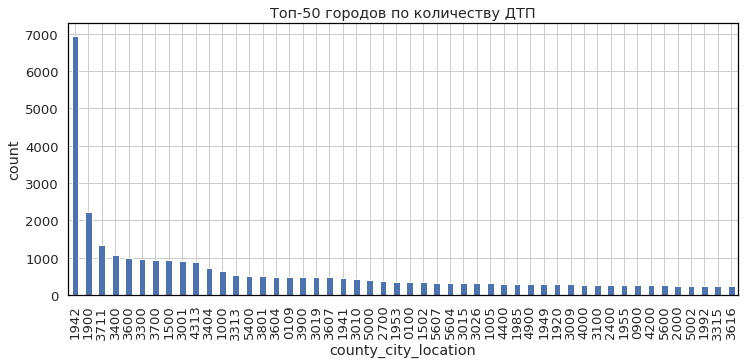

In [39]:
(df['county_city_location']
 .value_counts()
 .head(50)
 .plot(kind='bar',
       title='Топ-50 городов по количеству ДТП',
       ylabel='count',
       figsize=(12,5))
);

LA естественно на первом месте

В топ-50 городов происходит чуть больше половины всех ДТП - около 52 %. Остальные города заменим на `-1` 

In [40]:
main_loc = df['county_city_location'].value_counts().nlargest(50).index
df['county_city_location'] = df['county_city_location'].apply(lambda x: x if x in main_loc else -1)
df['county_city_location'] = df['county_city_location'].astype(int)

- Можно заметить, что первые две цифры это условный код города, тогда можем в принципе выбросить общую локацию и оставить районную, но их слишком много для перевода в категорийный тип (с одной стороны)
- С другой стороны, можно оставить категорию городов, а код будет подкатегорией, как бы secondary, для деревьев в теории самое оно. Вопрос только оставить численным признак как некий Ordinal, но без конкретного порядка, или все-таки закодировать в текст и потом OHE

#### Погодные условия

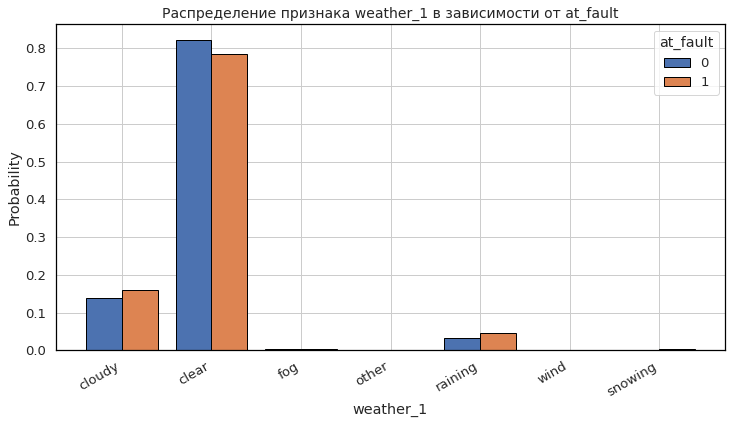

In [41]:
describe_column(df['weather_1'], hue=df['at_fault'])

In [42]:
df['weather_1'].fillna('other', inplace=True)

- Видно, что в неясную погоду ДТП происходит немного чаще, чем в ясную, среди всех ДТП
- Пропуски заполним `other`

#### Дорожное покрытие

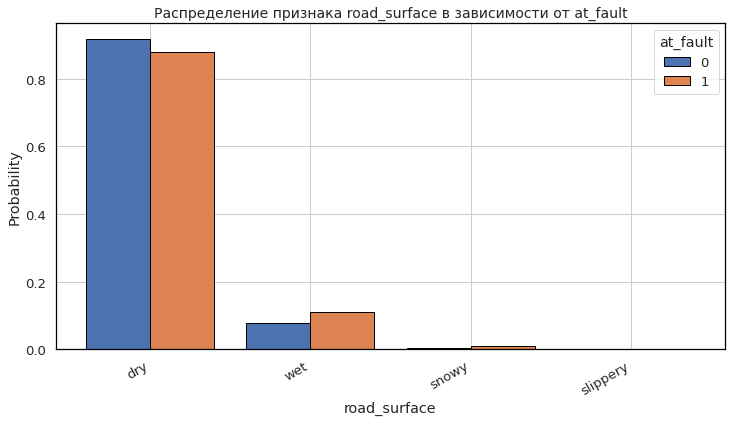

In [43]:
describe_column(df['road_surface'], hue=df['at_fault'])

In [44]:
df.dropna(subset='road_surface', inplace=True)

- Так как дело происходит в Калифорнии, то 90% времени и мест дорожное покрытие сухое, что логично
- ДТП происходят чуть чаще на не сухом покрытии
- Пропуски выбросим

#### День недели

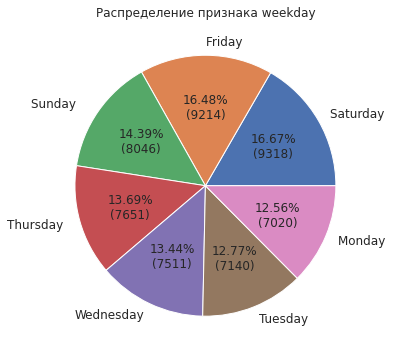

In [45]:
describe_column(df['weekday'])

Больше всего ДТП в пятницу и воскресенье, когда все выезжают и возвращаются с выходных

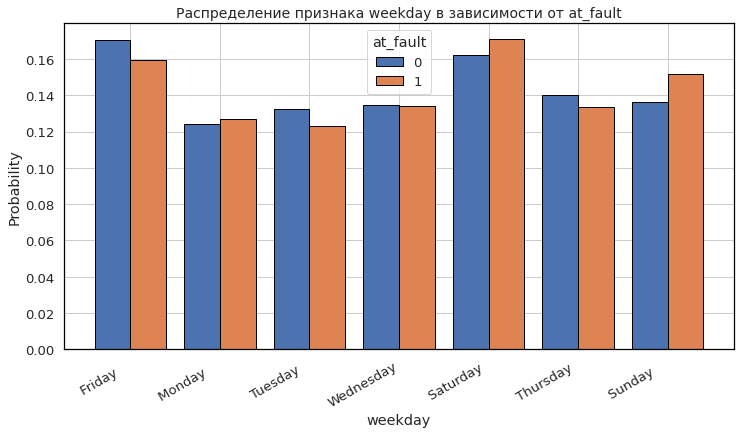

In [46]:
describe_column(df['weekday'], hue=df['at_fault'])

При этом в воскресенье и субботу больше попадают в ДТП с участием одной машины и другим участником (не машиной)

#### Час

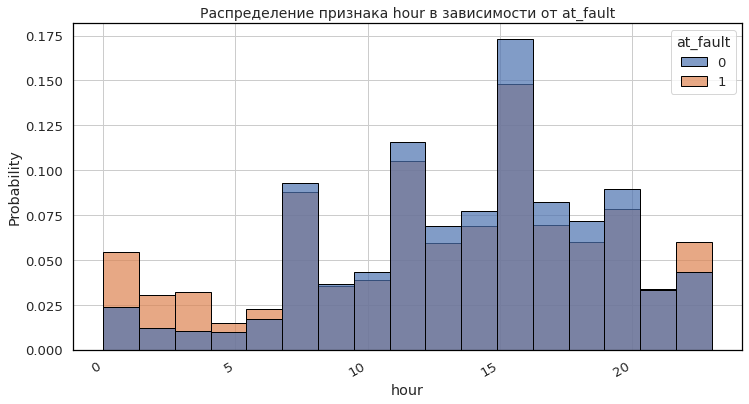

In [47]:
describe_column(df['hour'], hue=df['at_fault'], alpha=0.7)

In [48]:
df.dropna(subset='hour', inplace=True)

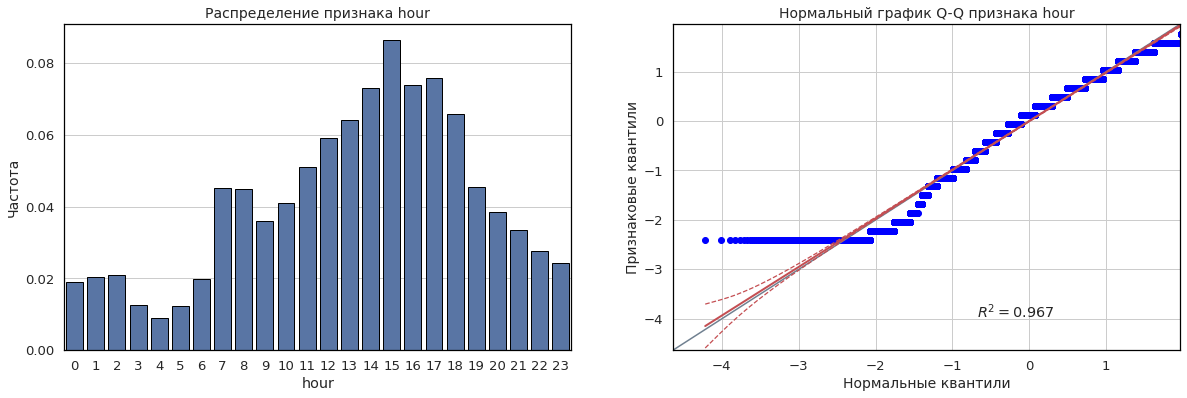

,count,mean,std,min,25%,50%,75%,max
hour,55814.0,13.312072,5.526274,0.0,10.0,14.0,17.0,23.0


In [49]:
describe_column(df['hour'].astype(int))

- В ночные часы ДТП явно меньше по понятным причинам, но риск при этом возрастает
- В пиковое значение 15 часов можно добавить для пользователя уведомление о росте ДТП в эти часы
- Пропуски выбросим

#### Освещение

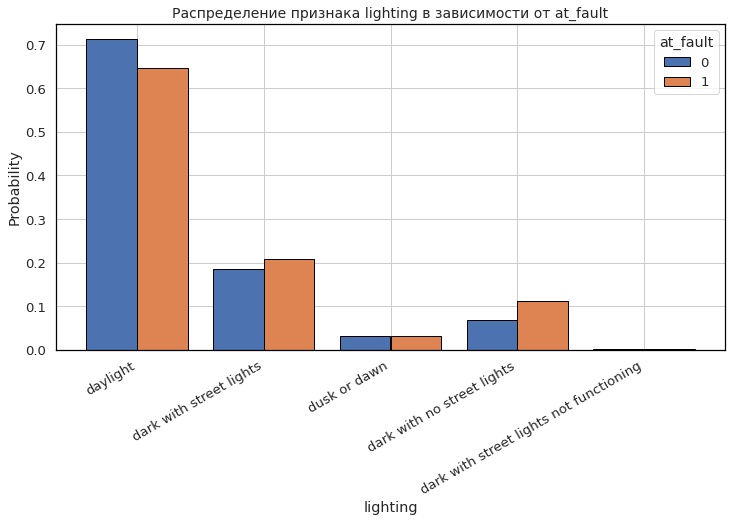

In [50]:
describe_column(df['lighting'], hue=df['at_fault'])

In [51]:
df.dropna(subset='lighting', inplace=True)

Объединим 3 категории когда было темно в 1 - `dark w/wo street lights`, так как солнечное освещение мы можем понять заранее

In [52]:
dark_col = [
    'dark with no street lights',
    'dark with street lights',
    'dark with street lights not functioning'
]
df['lighting'].where(~df['lighting'].isin(dark_col), 
                                other='dark w/wo street lights', 
                                inplace=True)

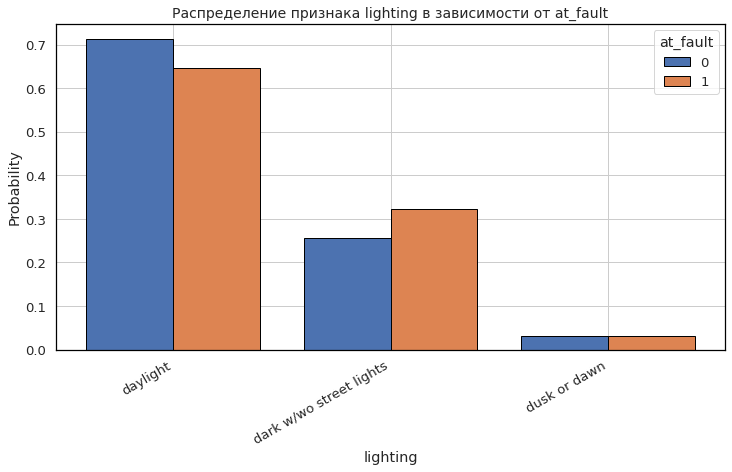

In [53]:
describe_column(df['lighting'], hue=df['at_fault'])

- Больше ДТП происходит в темное время суток с и без наличия уличного освещения
- Пропуски выбросим

#### Трезвость участника

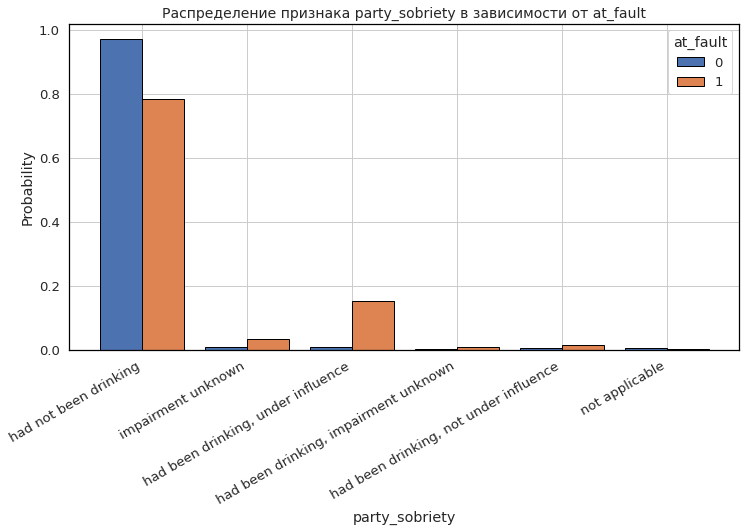

In [54]:
describe_column(df['party_sobriety'], hue=df['at_fault'])

In [55]:
df['party_sobriety'].unique()

array(['had not been drinking', 'impairment unknown',
       'had been drinking, under influence',
       'had been drinking, impairment unknown', None,
       'had been drinking, not under influence', 'not applicable'],
      dtype=object)

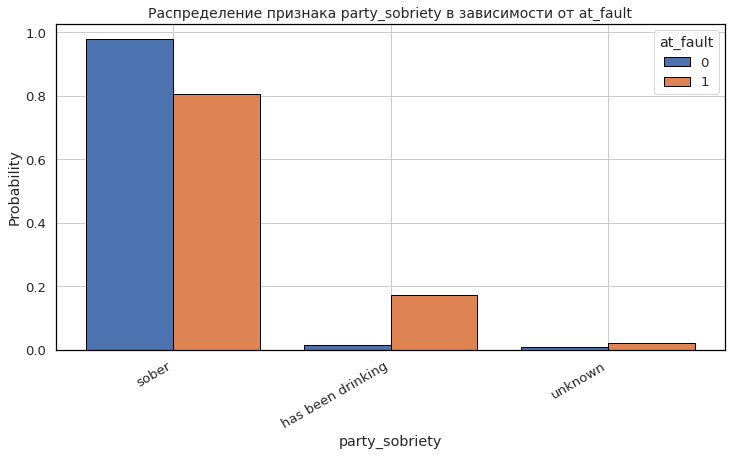

In [56]:
df['party_sobriety'].fillna('unknown', inplace=True)
drink_col = ['had been drinking, under influence',
             'had been drinking, impairment unknown',
             'had been drinking, not under influence'
            ]
df['party_sobriety'].where(df['party_sobriety'].isin(drink_col + ['unknown']), 
                                other='sober', 
                                inplace=True)
df['party_sobriety'].where(~df['party_sobriety'].isin(drink_col), 
                                other='has been drinking', 
                                inplace=True)
df['party_sobriety'].where(df['party_sobriety']!='impairment unknown',
                           other='unknown',
                           inplace=True)
describe_column(df['party_sobriety'], hue=df['at_fault'])

- В признаке наблюдаются серьезные различия, которые очевидны по своим причинам, если водитель пил, то вероятнее он станет виновником ДТП
- Пропуски заполнили `unknown`

#### Тип автомобиля

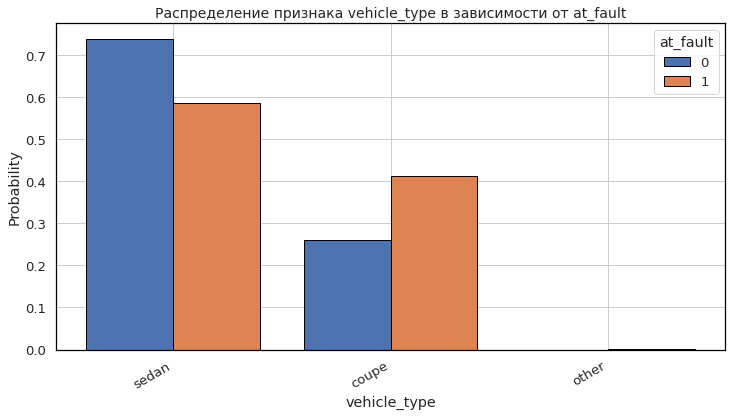

In [57]:
describe_column(df['vehicle_type'], hue=df['at_fault'])

In [58]:
df['vehicle_type'].fillna('other', inplace=True)

- К сожалению есть только типы авто - купе или седан, но нет более крупных авто
- Если водитель за рулем купе, то вероятность ДТП больше, чем если он будет за рулем седана, так как купе развивает большую скорость и из-за массы может иметь меньшую устойчивость
- Пропуски заполнили `other`

#### Коробка передач

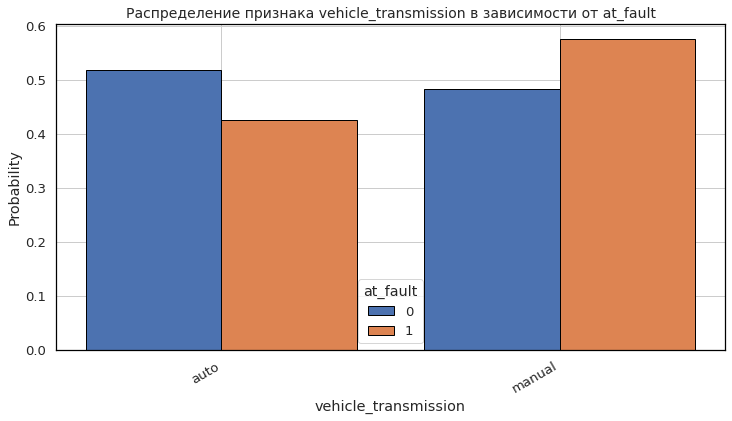

In [59]:
describe_column(df['vehicle_transmission'], hue=df['at_fault'])

- ДТП вероятнее на авто с МКПП, чем с АКПП, так как водитель может быть менее опытен в сложных ситуациях для МКПП
- Пропуски заполним `unknown`

In [60]:
df['vehicle_transmission'].fillna('unknown', inplace=True)

#### Возраст автомобиля

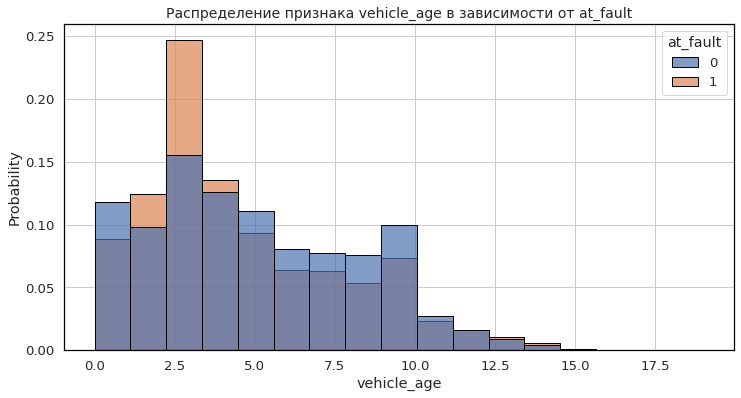

In [61]:
describe_column(df.query('vehicle_age<100')['vehicle_age'], hue=df['at_fault'], alpha=0.7)

In [62]:
df['vehicle_age'].fillna(-1, inplace=True)

ДТП происходит чаще с автомобилями возрастом 2-3 года, вероятно, когда стираются тормозные колодки или начинаются другие первые проблемы до первого серьезного ТО

#### Разговор по телефону за рулем

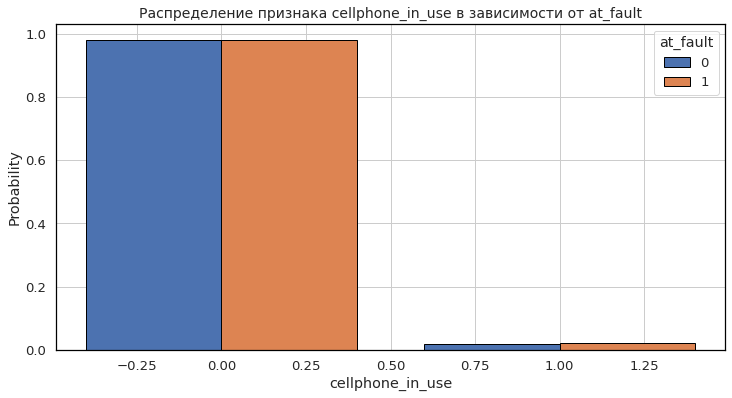

In [63]:
describe_column(df['cellphone_in_use'], hue=df['at_fault'])

Чуть больше ДТП, если разговаривал за рулем, пропуски заменим на `-1`

In [64]:
df['cellphone_in_use'].fillna(-1, inplace=True)

In [65]:
df[['cellphone_in_use', 'hour']] = df[['cellphone_in_use', 'hour']].astype(int)

#### Вывод

- Целевой признак распределен почти симметрично
    - 50.4 % - виновники
    - 49.6 % - пострадавшие
- `county_location` - оставили топ-15, остальные убрали в `other` в крупных округах больше машин, а следовательно ДТП
- `county_city_location` - оставили топ-50 городов, остальные убрали в `other`
- `weather_1` - в неясную погоду ДТП происходит немного чаще, чем в ясную. Пропуски заполнили `other`
- `road_surface` - ДТП происходят чуть чаще на не сухом покрытии. Пропуски выбросили
- `weekday` - больше всего ДТП в пятницу, а меньше всего в воскресенье из-за загруженности дорог
- `hour` - в ночные часы ДТП явно меньше по понятным причинам. Пропуски выбросили
- `lighting` - больше ДТП происходит в темное время суток с и без наличия уличного освещения - принудительный ближний свет. Пропуски выбросили
- `party_sobriety` - если водитель в нетрезвом состоянии, то вероятнее он станет виновником ДТП. Возможно, в будущем стоит включить в обсуждение данный признак, в моделировании использовать не будем
- `vehicle_type` - Если водитель за рулем купе, то вероятность ДТП больше, чем если он будет за рулем седана, так как купе развивает большую скорость и из-за массы может иметь меньшую устойчивость. Пропуски заполнили `other`
- `vehicle_transmission`- ДТП вероятнее на авто с МКПП, чем с АКПП, так как водитель может быть менее опытен в сложных ситуациях для МКПП. Пропуски заполнили `unknown`
- `cellphone_in_use` - чуть больше ДТП, если разговаривал за рулем, пропуски заменим на `-1`
- `vehicle_age` - авто возрастом 2-3 года чаще попадают в ДТП, видимо из-за износа перед первым ТО. пропуски заполнили `-1` 

### Корреляционный анализ

In [66]:
interval_cols = []
corr_matrix = df.phik_matrix(interval_cols=interval_cols)

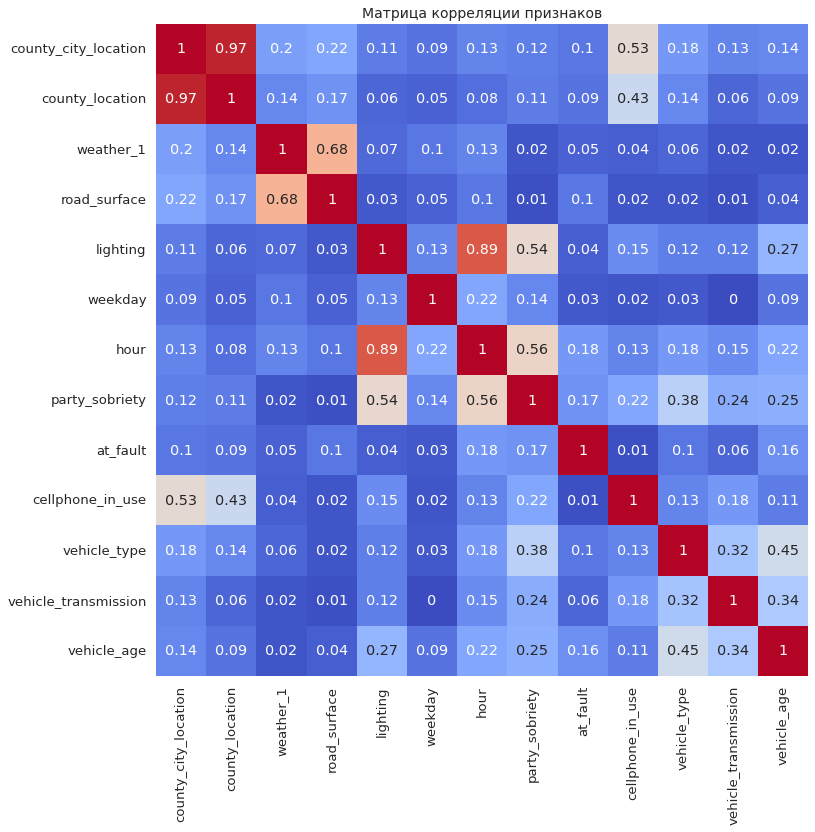

In [67]:
plt.figure(figsize=(12, 12))
plt.title('Матрица корреляции признаков',
          fontsize=14)
sns.heatmap(corr_matrix.round(2), 
            annot = True, square=True, 
            cmap='coolwarm', 
            cbar=False);

С целевым признаком заметно коррелирует только
- час - 0.18
- трезвость водителя - 0.17
- возраст авто - 0.16

Видим, что корреляция с трезвостью водителя на заметном уровне, еще один довод в пользу рассмотрения данного признака в будущем. Далее в моделировании его использовать не будем, поэтому выбросим его и заново посмотрим на матрицу корреляции

In [68]:
df.drop('party_sobriety', axis=1, inplace=True)
corr_matrix = df.phik_matrix(interval_cols=interval_cols)

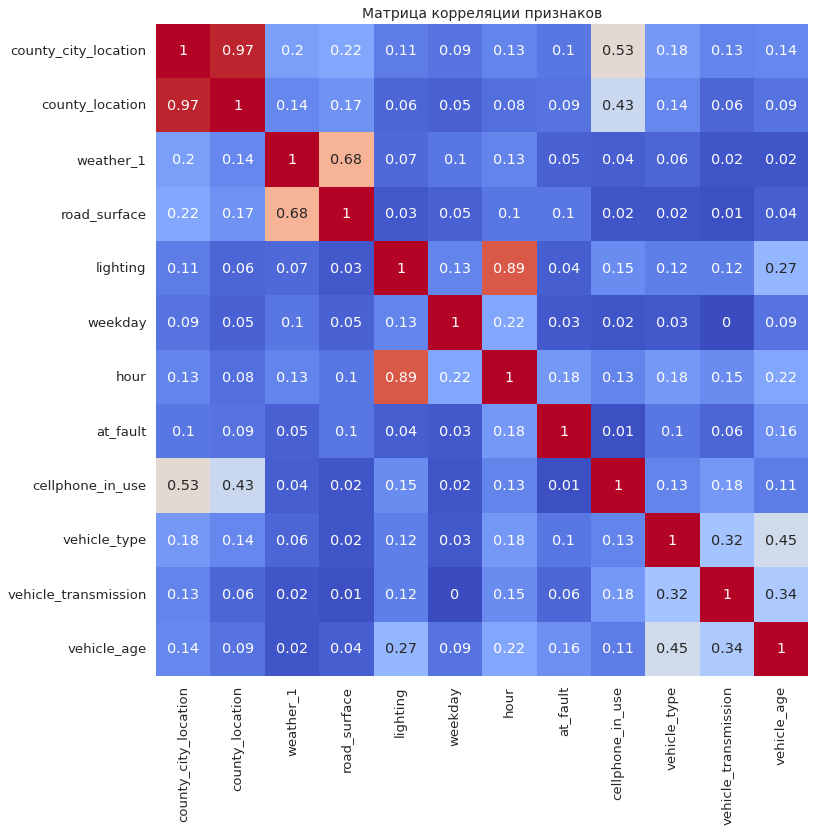

In [69]:
plt.figure(figsize=(12, 12))
plt.title('Матрица корреляции признаков',
          fontsize=14)
sns.heatmap(corr_matrix.round(2), 
            annot = True, square=True, 
            cmap='coolwarm', 
            cbar=False);

Теперь с целевым признаком заметно коррелирует только
- час - 0.18
- возраст авто - 0.16

Посмотрим на разницу корреляции между признаками для виновников и пострадавших в ДТП

In [70]:
corr_matrix_0 = df.query('at_fault==0').phik_matrix(interval_cols=interval_cols)
corr_matrix_1 = df.query('at_fault==1').phik_matrix(interval_cols=interval_cols)
dif_corr_matrix = corr_matrix_1 - corr_matrix_0

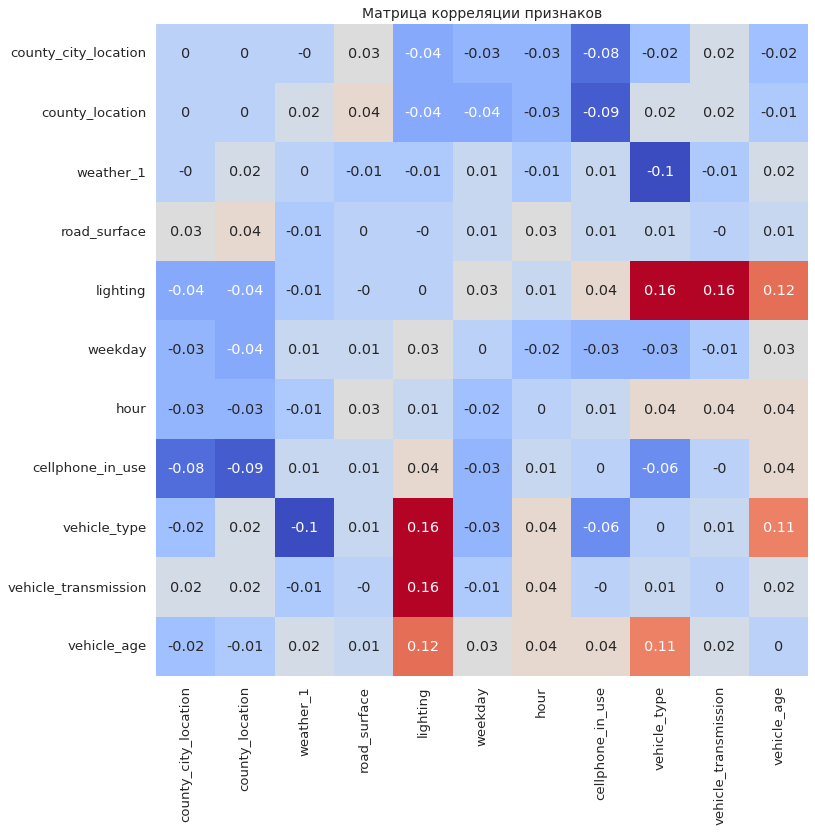

In [71]:
plt.figure(figsize=(12, 12))
plt.title('Матрица корреляции признаков',
          fontsize=14)
sns.heatmap(dif_corr_matrix.round(2), 
            annot = True, square=True, 
            cmap='coolwarm', 
            cbar=False);

На разнице видно, что на ДТП оказывает влияние корреляция следующих признаков
- Освещение и признаки автомобиля - в среднем около 0.15
- Возраст автомобиля и его тип - 0.11

### Вывод

- Из базы данных отобрали следующие признаки
    - Целевой признак распределен почти симметрично
        - 50.4 % - виновники
        - 49.6 % - пострадавшие
    - `county_location` - оставили топ-15, остальные убрали в `other` в крупных округах больше машин, а следовательно ДТП
    - `county_city_location` - оставили топ-50 городов, остальные убрали в `other`
    - `weather_1` - в неясную погоду ДТП происходит немного чаще, чем в ясную. Пропуски заполнили `other`
    - `road_surface` - ДТП происходят чуть чаще на не сухом покрытии. Пропуски выбросили
    - `weekday` - больше всего ДТП в пятницу, а меньше всего в воскресенье из-за загруженности дорог
    - `hour` - в ночные часы ДТП явно меньше по понятным причинам. Пропуски выбросили
    - `lighting` - больше ДТП происходит в темное время суток с и без наличия уличного освещения - принудительный ближний свет. Пропуски выбросили
    - `party_sobriety` - если водитель в нетрезвом состоянии, то вероятнее он станет виновником ДТП. Видим, что корреляция с трезвостью водителя на заметном уровне, еще один довод в пользу рассмотрения данного признака в будущем. **В моделировании его использовать не будем**
    - `vehicle_type` - Если водитель за рулем купе, то вероятность ДТП больше, чем если он будет за рулем седана, так как купе развивает большую скорость и из-за массы может иметь меньшую устойчивость. Пропуски заполнили `other`
    - `vehicle_transmission`- ДТП вероятнее на авто с МКПП, чем с АКПП, так как водитель может быть менее опытен в сложных ситуациях для МКПП. Пропуски заполнили `unknown`
    - `cellphone_in_use` - чуть больше ДТП, если разговаривал за рулем, пропуски заменим на `-1`
    - `vehicle_age` - авто возрастом 2-3 года чаще попадают в ДТП, видимо из-за износа перед первым ТО. пропуски заполнили `-1`
    
    
- Анализ корреляции показал следующее
    - С целевым признаком заметно коррелирует только
        - час - 0.18
        - трезвость водителя - 0.17
        - возраст авто - 0.16
    - На разнице видно, что на ДТП оказывает влияние корреляция следующих признаков, по ним сделаем предложения заказчику
        - Освещение и признаки автомобиля - в среднем около 0.15
        - Возраст автомобиля и его тип - 0.11

## Модель для оценки водительского риска

### Обучение моделей

In [72]:
df = df.apply(lambda x: x.astype('category') if x.dtype=='O' else x)
df.reset_index(drop=True, inplace=True)

In [73]:
X = df.drop(['at_fault'], axis=1)
y = df['at_fault']

num_cols = [
            'hour', 
            'cellphone_in_use',
            'vehicle_age'
            ]

ord_1_cols = [
            'county_location',
            'county_city_location',
            'weather_1',
            'road_surface',
            'weekday'
            ]

ord_2_cols = [
            'lighting',
            'vehicle_type',
            'vehicle_transmission'
            ]

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.25,
                                                    stratify=y,
                                                    random_state=RANDOM_STATE)

In [74]:
# ORD
ord_1_pipe = Pipeline([
    (
        'imputer_before', 
         SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='unknown')
    ),
    (
        'ord',
         OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
    ),
    (
        'imputer_after', 
         SimpleImputer(missing_values=np.nan, strategy='most_frequent')
    )    
])

# ORD
ord_2_pipe = Pipeline([
    (
        'imputer_before', 
         SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='other')
    ),
    (
        'ord',
         OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
    ),
    (
        'imputer_after', 
         SimpleImputer(missing_values=np.nan, strategy='most_frequent')
    )    
])

In [75]:
# Preprocessor = CAT + ORD + NUM
preprocessor = ColumnTransformer(
    [
        ('ord_1', ord_1_pipe, ord_1_cols),
        ('ord_2', ord_2_pipe, ord_2_cols),
    ],
    remainder='passthrough')

# Preprocessor + Models
pipe_search = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ])

- Подготовим функцию для обучения и сбора статистики по лучшей модели
- Для бизнеса нам важнее баланс Precision и Recall с уклоном в Recall, чтобы как можно больше снизить риск ДТП, при это не сильно раздражая и терять клиентов, поэтому в идеале F1-метрика, либо ROC-AUC
- Так как данные сбалансированы, то для сравнения моделей будем пользоваться метрикой ROC-AUC

In [76]:
def objective(params, model_type, X, y):
    
    model = model_type.set_params(**params)
    skf = StratifiedKFold(n_splits=3, random_state=RANDOM_STATE, shuffle=True)
    score = cross_val_score(estimator=model, X=X, y=y, 
                            scoring='roc_auc', cv=skf)

    return {'loss': -score.mean(),
            'status': STATUS_OK,
            'model': model
           }

In [77]:
def model_search(model_type, param_search, name, X_train, y_train, eval_num=10):
    
    if name == 'RandomForest':
        model = RandomizedSearchCV(
            model_type,
            param_search,
            cv=3,
            scoring='roc_auc',
            n_iter=eval_num,
            n_jobs=4,
            verbose=1,
            random_state=RANDOM_STATE
        )
        model.fit(X_train, y_train)
    else: 
        trials = Trials()
        results = fmin(
                        partial(objective, model_type=model_type, X=X_train, y=y_train),
                        space=param_search,
                        algo=tpe.suggest,
                        trials=trials,
                        max_evals=eval_num,
                        rstate=np.random.default_rng(42)
                      )

        
    
    start = time.time()
    if name == 'RandomForest':
        best_model = model.best_estimator_
        best_loss = round(model.best_score_, 3)
    else:
        best_model, best_loss = getBestModelfromTrials(trials)
    best_model.fit(X_train, y_train)
    end = time.time()
    fit_time = round(end-start, 2)
    
    start = time.time()
    pred = best_model.predict(X_train)
    end = time.time()
    predict_time = round(end-start, 2)
    print(f'Время обучения лучшей модели: {predict_time} секунд')
    print(f'ROC-AUC лучшей модели: {best_loss}')
    display(best_model)
    results = {'model': name,
               'cv_roc_auc': best_loss,
               'fit_time': fit_time,
               'predict_time': predict_time
              }
    
    return best_model, results

In [78]:
def getBestModelfromTrials(trials):
    valid_trial_list = [trial for trial in trials
                            if STATUS_OK == trial['result']['status']]
    losses = [ float(trial['result']['loss']) for trial in valid_trial_list]
    index_having_minumum_loss = np.argmin(losses)
    best_trial_obj = valid_trial_list[index_having_minumum_loss]
    return best_trial_obj['result']['model'], -round(best_trial_obj['result']['loss'], 3)

Будем обучать три вида моделей: 
- Дерево решений
- Случайный лес
- Градиентный бустинг - LGBM

In [79]:
%%time
decision_tree_param = {
                       'model': DecisionTreeClassifier(random_state=RANDOM_STATE),
                       'model__criterion' : hp.choice('model__criterion', 
                                                      ['gini', 'entropy', 'log_loss']),
                       'model__max_depth': hp.choice('model__max_depth', 
                                                     np.arange(8, 21, dtype=int)),
                       'model__min_samples_leaf': hp.choice('model__min_samples_leaf', 
                                                            np.arange(10, 121, 11))    
                      }
model_tree, res_tree = model_search(pipe_search, 
                                    decision_tree_param, 
                                    'DecisionTree',
                                    X_train.apply(lambda x: x.astype('O') if x.dtype=='category' else x),
                                    y_train,
                                    eval_num=20)

100%|██████████| 20/20 [00:12<00:00,  1.67trial/s, best loss: -0.6381606204709448]
Время обучения лучшей модели: 0.09 секунд
ROC-AUC лучшей модели: 0.638


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord_1',
                                                  Pipeline(steps=[('imputer_before',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('imputer_after',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['county_location',
                                                   'count...
                                                                   SimpleImputer(fill_value='other',
                                                                                 strategy='constant')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('imputer_after',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['lighting', 'vehicle_type',
                                                   'vehicle_transmission'])])),
                ('model',
                 DecisionTreeClassifier(criterion='entropy', max_depth=13,
                                        min_samples_leaf=32,
                                        random_state=42))])

CPU times: user 12.4 s, sys: 10.3 ms, total: 12.4 s
Wall time: 12.5 s


In [80]:
%%time
lgbm_param = {
              'reg_lambda' : hp.uniform('reg_lambda', 0, 10),
              'max_depth': hp.choice('max_depth', np.arange(0, 3, dtype=int)),
              'n_estimators' : hp.choice('n_estimators', np.arange(500, 3001, 500, dtype=int)),
              'learning_rate': hp.choice('learning_rate', [0.01, 0.1, 1.]),
              'colsample_bytree': hp.choice('colsample_bytree', [0.5, 0.75, 1.])
             }
model_lgbm, res_lgbm = model_search(LGBMClassifier(random_state=RANDOM_STATE, 
                                                   n_jobs=-1, 
                                                   verbose=-1),
                                    lgbm_param,
                                    'LGBM',
                                    X_train,
                                    y_train,
                                    eval_num=5)

100%|██████████| 5/5 [02:13<00:00, 26.74s/trial, best loss: -0.6507405831974546]
Время обучения лучшей модели: 13.0 секунд
ROC-AUC лучшей модели: 0.651


LGBMClassifier(colsample_bytree=0.5, learning_rate=0.01, max_depth=0,
               n_estimators=2000, random_state=42, reg_lambda=5.029037546614818,
               verbose=-1)

CPU times: user 2min 42s, sys: 2.05 s, total: 2min 44s
Wall time: 2min 46s


In [81]:
%%time
random_forest_param = {
                       'model': [RandomForestClassifier(random_state=RANDOM_STATE, 
                                                        n_jobs=-1)],
                       'model__n_estimators' : np.arange(100, 601, 100),
                       'model__criterion' : ['gini', 'entropy'], 
                       'model__max_depth': np.arange(8, 21, 2),
                       'model__min_samples_leaf': np.arange(10, 121, 11)
                      }
model_forest, res_forest = model_search(pipe_search, 
                                        random_forest_param, 
                                        'RandomForest',
                                        X_train.apply(lambda x: x.astype('O') if x.dtype=='category' else x),
                                        y_train,
                                        eval_num=10)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Время обучения лучшей модели: 0.37 секунд
ROC-AUC лучшей модели: 0.648


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord_1',
                                                  Pipeline(steps=[('imputer_before',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('imputer_after',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['county_location',
                                                   'count...
                                                  Pipeline(steps=[('imputer_before',
                                                                   SimpleImputer(fill_value='other',
                                                                                 strategy='constant')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('imputer_after',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['lighting', 'vehicle_type',
                                                   'vehicle_transmission'])])),
                ('model',
                 RandomForestClassifier(max_depth=8, min_samples_leaf=65,
                                        n_jobs=-1, random_state=42))])

CPU times: user 6.08 s, sys: 413 ms, total: 6.49 s
Wall time: 3min 22s


### Сравнение моделей и выбор лучшей

In [82]:
comparison = pd.DataFrame({key: [res_tree[key], 
                                 res_forest[key], 
                                 res_lgbm[key]] for key in res_tree})
comparison = comparison.sort_values(by='cv_roc_auc', ascending=False)

,model,cv_roc_auc,fit_time,predict_time
2,LGBM,0.651,19.70,13.00
1,RandomForest,0.648,2.08,0.37
0,DecisionTree,0.638,0.26,0.09


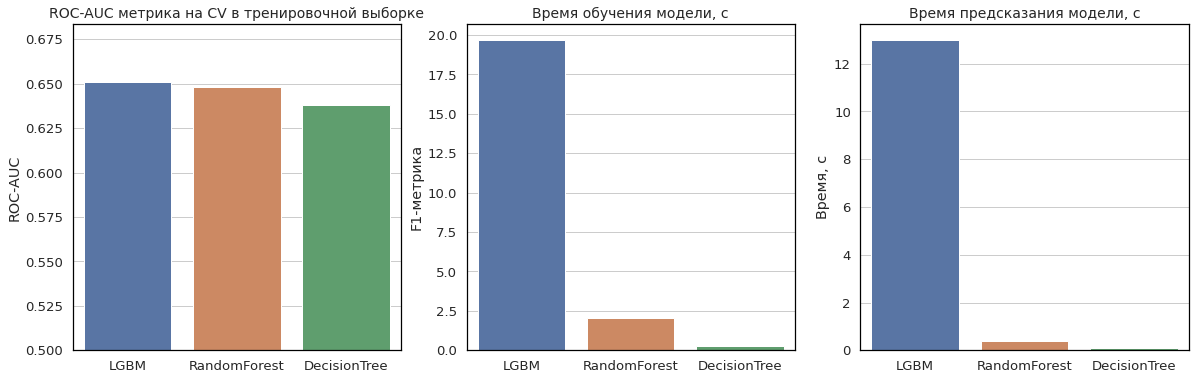

In [83]:
titles = [
          'ROC-AUC метрика на CV в тренировочной выборке', 
          'Время обучения модели, с',
          'Время предсказания модели, с'
         ]
ylabel = [
          'ROC-AUC',
          'F1-метрика',
          'Время, с',
          'Время, с'
         ]
fig, ax = plt.subplots(1, 3, figsize=(20,6))
for idx, col in enumerate(comparison.iloc[:,1:]):
    bar = sns.barplot(data=comparison, 
                      x='model', 
                      y=col,
                      hue='model',
                      ax=ax[idx])
    bar.set_title(f'{titles[idx]}', fontsize=14)
    bar.set_xlabel('')
    bar.set_ylabel(f'{ylabel[idx]}')
    
ax[0].set_ylim(bottom=0.5)
ax[0].set_ylim(bottom=0.5)
comparison

- ROC-AUC метрики у всех моделей довольно близкие
    - LGBM - 0.651
    - Random Forest - 0.648
    - Decision Tree - 0.638
- Время предсказания самое долгое у LGBM (плохо параллелится на сервере Практикума)
- Выберем Random Forest, так как лучший по метрикам (ROC-AUC и F1) и среднее время предсказания

In [84]:
best_model = model_forest
best_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord_1',
                                                  Pipeline(steps=[('imputer_before',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('imputer_after',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['county_location',
                                                   'count...
                                                  Pipeline(steps=[('imputer_before',
                                                                   SimpleImputer(fill_value='other',
                                                                                 strategy='constant')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('imputer_after',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['lighting', 'vehicle_type',
                                                   'vehicle_transmission'])])),
                ('model',
                 RandomForestClassifier(max_depth=8, min_samples_leaf=65,
                                        n_jobs=-1, random_state=42))])

### Калибровка модели

Посмотрим на калибровочную кривую модели

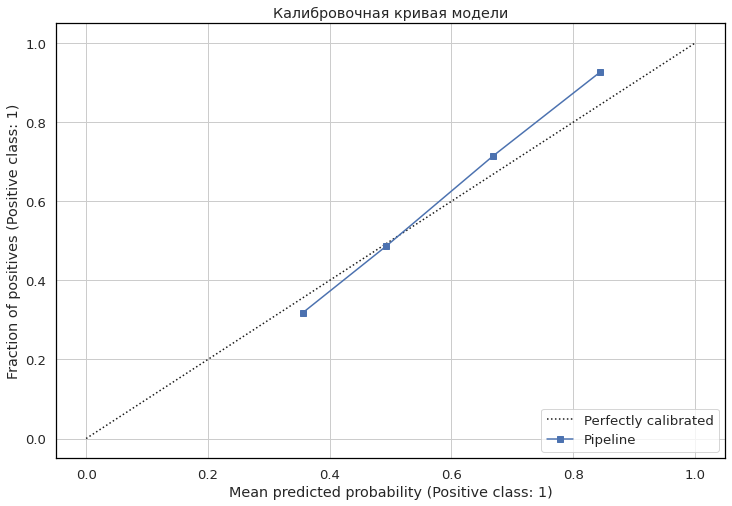

In [85]:
disp = CalibrationDisplay.from_estimator(best_model, X_test, y_test)
disp.figure_.set_size_inches(12, 8)
plt.title('Калибровочная кривая модели');

Откалибруем модель, чтобы она показывала вероятности

In [87]:
best_model_cal = (CalibratedClassifierCV(best_model, cv=3, method='isotonic')
    .fit(X_train, y_train))
y_pred = best_model_cal.predict(X_test)
y_proba = best_model_cal.predict_proba(X_test)[:,1]

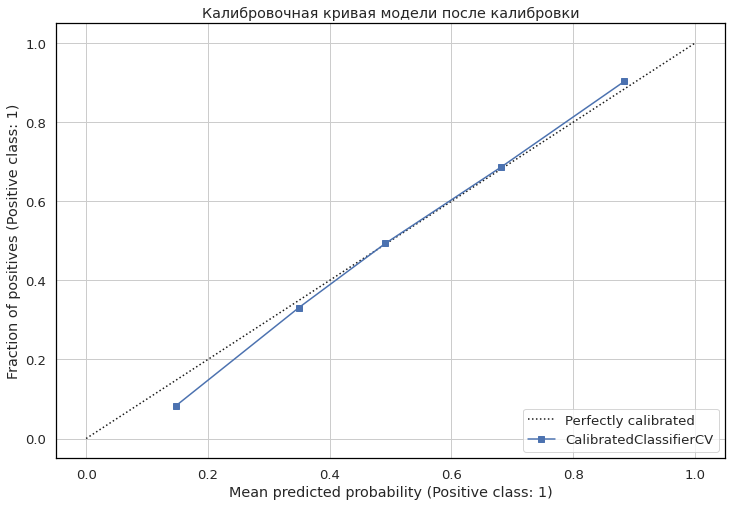

In [88]:
disp = CalibrationDisplay.from_estimator(best_model_cal, X_test, y_test)
disp.figure_.set_size_inches(12, 8)
plt.title('Калибровочная кривая модели после калибровки');

### Анализ лучшей модели

In [89]:
# Создадим функцию для вывода метрики модели
# Принимает на вход y_test - тестовая выборка, predictions - предсказание целевого признака
def model_metrics(y_test, predictions, proba, name):
    print(f'ROC-AUC - {round(roc_auc_score(y_test, proba), 3)}')
    print(f'Recall - {round(recall_score(y_test, predictions), 3)}')
    print(f'Precision - {round(precision_score(y_test, predictions), 3)}')
    print(f'F1 score - {round(f1_score(y_test, predictions), 3)}')
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
    plt.title(f'Матрица ошибок {name}')
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Истинный класс')

In [90]:
pred_train_cv = cross_val_predict(best_model_cal, 
                                  X_train, 
                                  y_train, 
                                  cv=3, 
                                  method='predict')
pred_proba_train_cv = cross_val_predict(best_model_cal, 
                                        X_train, 
                                        y_train, 
                                        cv=3, 
                                        method='predict_proba')[:,1]

ROC-AUC - 0.647
Recall - 0.57
Precision - 0.62
F1 score - 0.594


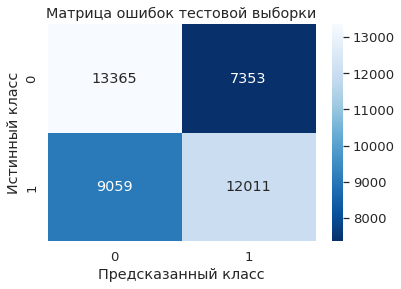

In [91]:
model_metrics(y_train,
              pred_train_cv,
              pred_proba_train_cv,
              'тестовой выборки')

Опишем матрицу ошибок

- Модель чуть лучше случайного выбора предсказывает виновника ДТП среди всех виновников (потенциальное ДТП) - 57.0 % (12011) и довольно хорошо пострадавшего (потенциальное не ДТП) - 64.5 % (13365)
- В то же время ошибки первого рода, т.е. определение пострадавшего как виновника ДТП (обычной поездки как потенциальное ДТП) составляют около 35.5 % (7353)
- Ошибки второго рода, т.е. определение виновника ДТП как пострадавшего (пропуск потенциального ДТП) составляют около 43 %
- Полнота модели, т.е. охват всех потенциальный ДТП 57.0 %, а точность - т.е. верные предсказния потенциальных ДТП из всех предсказаний - 62.0 %
- Нас интересует больше охват, так как из возможностей у бизнеса вероятно будет только уведомление в приложении, которое легко смахивается, но лучше заранее предупредить клиента о повышенной вероятности ДТП, чем пропустить такое
- Попробуем слегка сместить порог для уменьшения ошибок второго рода и увеличения охвата за счет точности

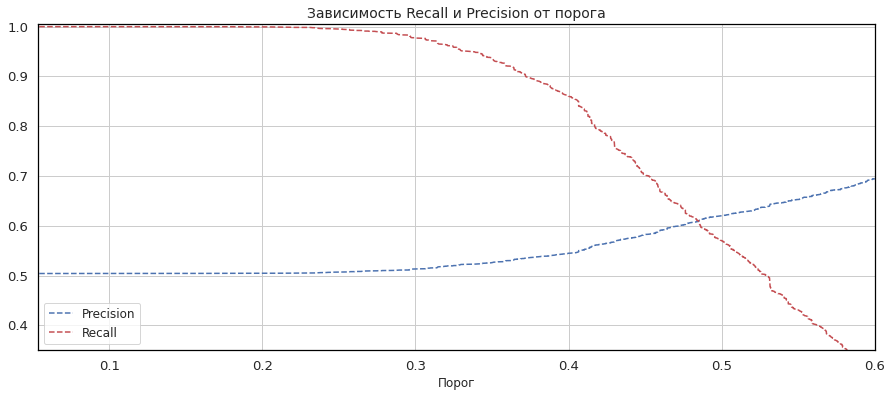

In [92]:
# Найдем все значения precision, recall и порога для тестовой выборки и предсказаний
precision, recall, threshold  = precision_recall_curve(y_train, 
                                                       pred_proba_train_cv)

# Построим графики зависимостей
plt.figure(figsize=(15,6))
plt.title('Зависимость Recall и Precision от порога', fontsize=14)
plt.plot(threshold, precision[:-1], 'b--', label='Precision')
plt.plot(threshold, recall[:-1], 'r--', label='Recall')
plt.xlabel('Порог', fontsize=12)
plt.legend(loc='lower left', fontsize=12)
plt.ylim([0.35, 1.005])
plt.xlim([min(threshold)-0.001, 0.6])
plt.grid(True);

Выберем порог 0.41

ROC-AUC - 0.647
Recall - 0.836
Precision - 0.551
F1 score - 0.665


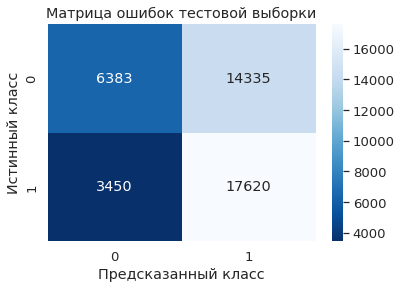

In [93]:
pred_train_cv_with_threshold = (pred_proba_train_cv > 0.41).astype(int)
model_metrics(y_train,
              pred_train_cv_with_threshold,
              pred_proba_train_cv,
              'тестовой выборки')

- Полнота модели, т.е. охват всех потенциальный ДТП поднялся до 0.836, а точность - т.е. верные предсказания потенциальных ДТП из всех предсказаний снизилась до 0.551

Теперь посмотреть метрику на тестовой выборке

ROC-AUC - 0.661
Recall - 0.835
Precision - 0.561
F1 score - 0.671


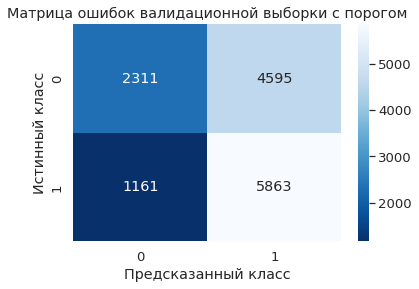

In [94]:
y_pred = best_model_cal.predict(X_test)
y_pred_proba = best_model_cal.predict_proba(X_test)[:,1]
# Немного варьируем порог и рассчитываем метрику модели с порогом
pred_with_threshold = (y_pred_proba > 0.41).astype(int)
model_metrics(y_test, 
              pred_with_threshold, 
              y_pred_proba, 
              'валидационной выборки с порогом')

- Модель хорошо находит виновника ДТП среди всех виновников (потенциальное ДТП) - 83.5 % (5863) и плохо пострадавшего (потенциальное не ДТП) - 33.4 % (2311)
- Определение пострадавшего как виновника ДТП (обычной поездки как потенциальное ДТП) составляют около 66.6 % (4595)
- Определение виновника ДТП как пострадавшего (пропуск потенциального ДТП) составляют около 16.5 %
- Полнота модели, т.е. охват всех потенциальных ДТП - 83.5 %, а точность - т.е. верные предсказния потенциальных ДТП из всех предсказаний - 56.1 %

Сравним результаты с Dummy классификатором

ROC-AUC - 0.501
Recall - 0.512
Precision - 0.505
F1 score - 0.509


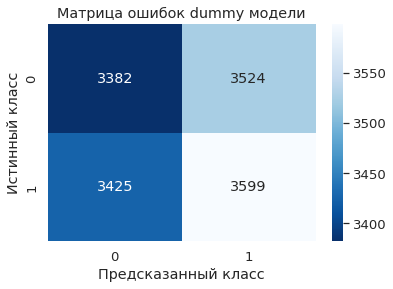

In [95]:
dummy_class = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy_class.fit(X_train, y_train)
y_dummy_predict = dummy_class.predict(X_test)
y_dummy_proba = dummy_class.predict_proba(X_test)[:,1]
model_metrics(y_test, y_dummy_predict, y_dummy_proba, 'dummy модели')

Наша модель явно лучше Dummy модели

### Анализ важности признаков

In [96]:
X_sample = (X_train
            .apply(lambda x: x.astype('O') if x.dtype=='category' else x)
            .sample(random_state=RANDOM_STATE, frac=0.2))
X_train_encoded = best_model['preprocessor'].transform(X_sample)
feature_names = best_model['preprocessor'].get_feature_names_out()
cols = [re.sub(r'^.+__','', x) for x in feature_names]
explainer = shap.TreeExplainer(
                                best_model['model'], 
                                X_train_encoded, 
                                feature_names=cols
                              )

shap_values = explainer(X_train_encoded)

100%|===================| 16651/16716 [03:03<00:00]        

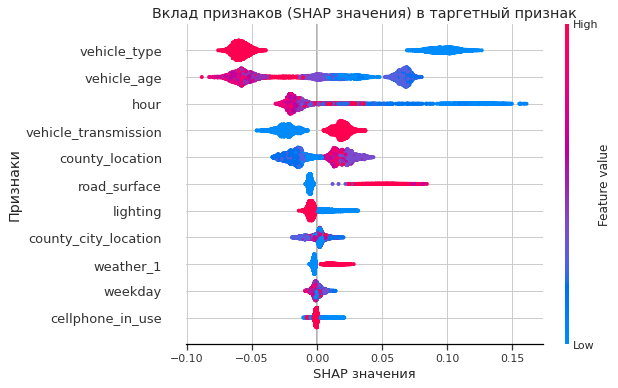

In [97]:
shap.plots.beeswarm(shap_values[:,:,1], max_display=18, show=False)
plt.title('Вклад признаков (SHAP значения) в таргетный признак')
plt.xlabel('SHAP значения')
plt.ylabel('Признаки');

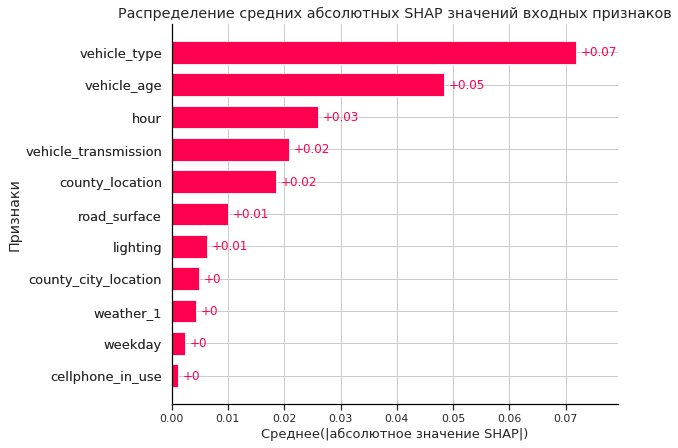

In [98]:
shap.plots.bar(shap_values[:,:,1], max_display=18, show=False)
plt.title('Распределение средних абсолютных SHAP значений входных признаков')
plt.xlabel('Среднее(|абсолютное значение SHAP|)')
plt.ylabel('Признаки');

- Важными признаками для модели являются
    - **Тип автомобиля**
    - **Возраст автомобиля**
    - **Час поездки**
    - Тип коробки передач
    - Геолоакция

Расммотрим их детальнее

In [99]:
# заполним пропуски в тренировочных данных для лейблов и распределений
df_ = pd.DataFrame(X_sample, columns=X_sample.columns)[cols]

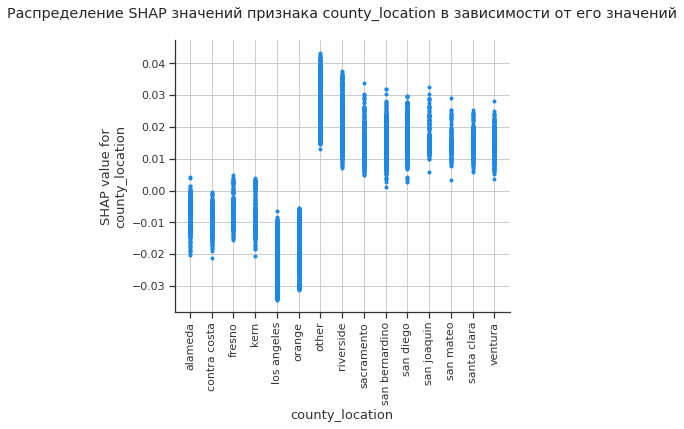

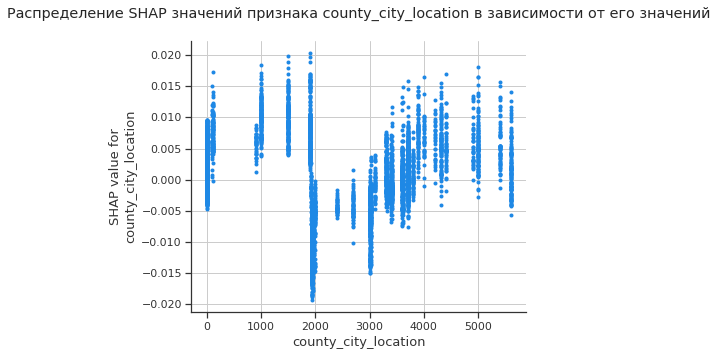

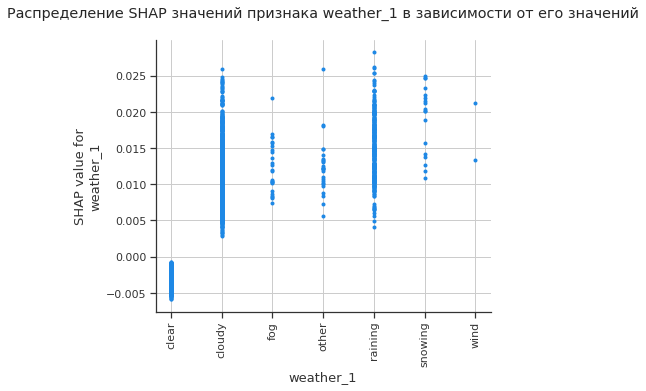

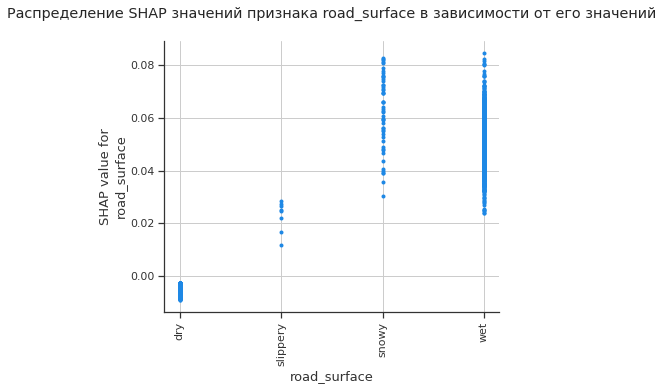

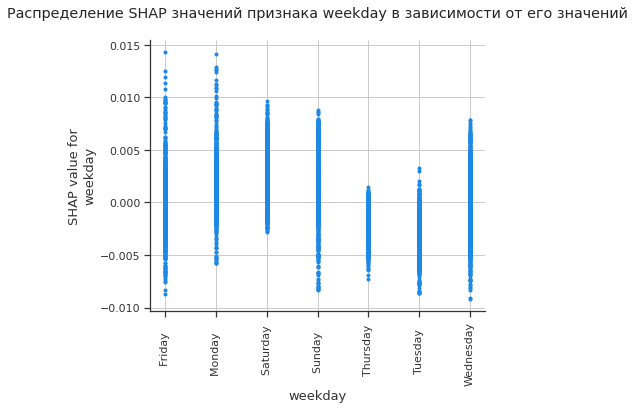

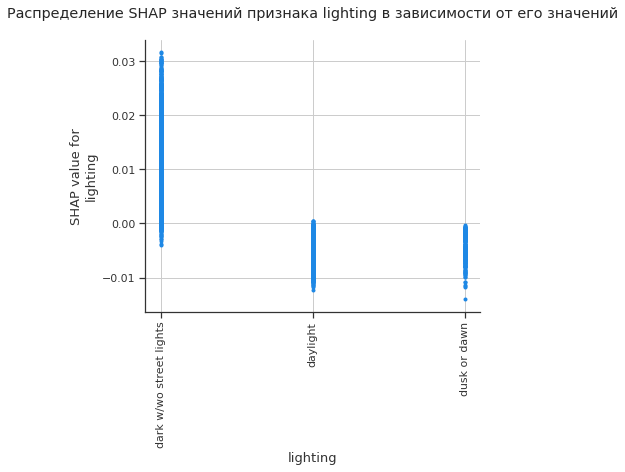

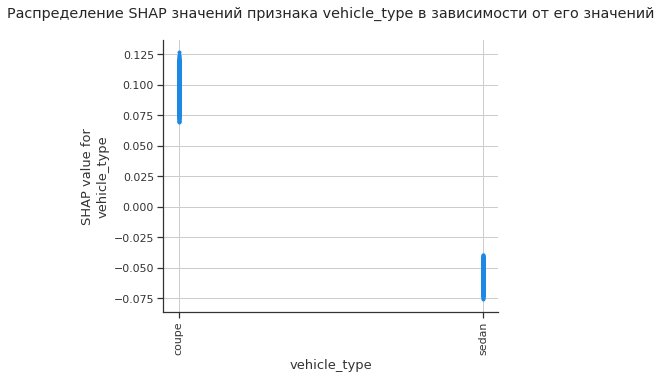

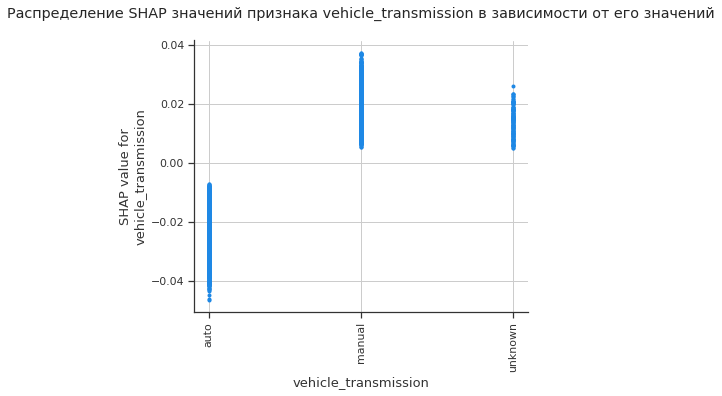

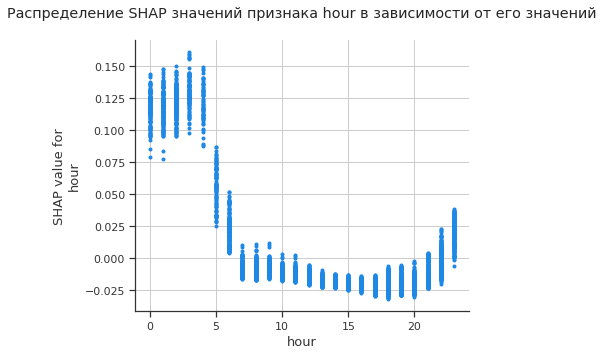

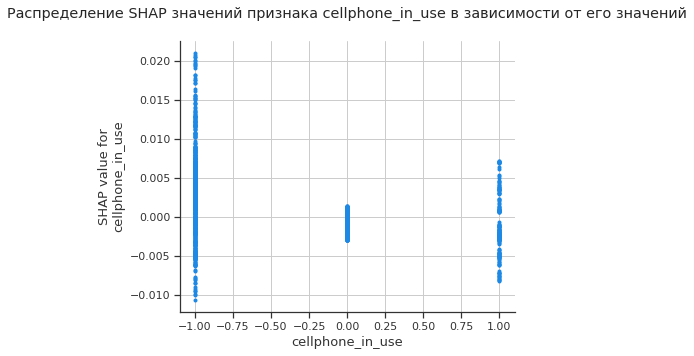

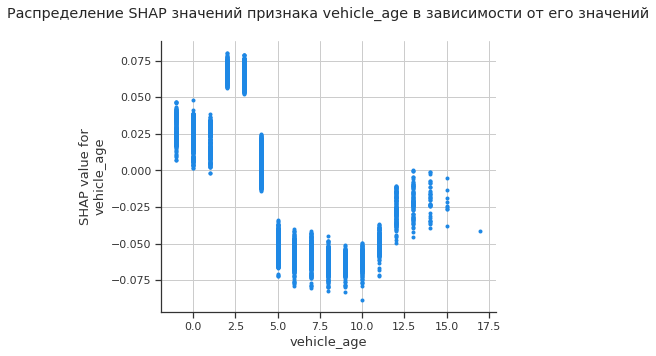

In [100]:
for i in range(len(feature_names)):
    shap.dependence_plot(
        i, 
        shap_values.values[:,:, 1],
        df_, 
        feature_names=cols,
        interaction_index=None,
        show=False
        )
    plt.title(f'Распределение SHAP значений признака {cols[i]} в зависимости от его значений\n')

- Трезвость участника
    - Если водитель в нетрезвом состоянии, вероятность ДТП резко возрастает

- Тип автомобиля
    - Купе с большей вероятностью может попасть в ДТП, чем седан, а так же МКПП чаще, чем АКПП
  
- Возраст автомобиля
    - В ДТП больше вероятность попасть у автомобилей до 3 лет, особенно в период 2-3 года. Связано скорее всего с износом деталей, либо заводским браком, который еще не был обнаружен на осмотре, либо не была проведена вовремя замена деталей

### Анализ важности факторов ДТП

#### Тип автомобиля

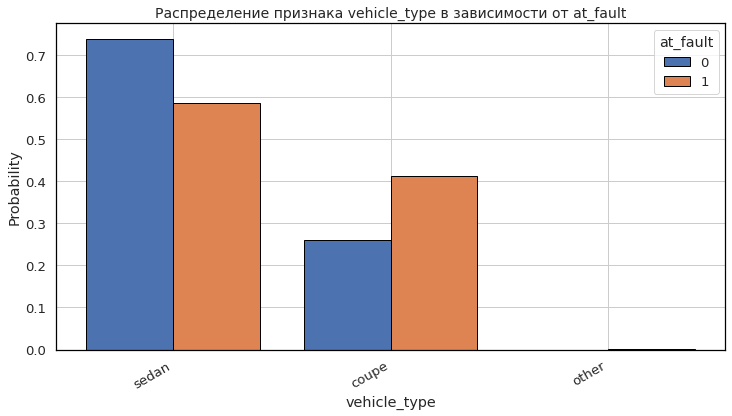
- Купе с большей вероятностью может попасть в ДТП, чем седан, а так же МКПП чаще, чем АКПП
- Ограничить выбор автомобилей клиентам в зависимости от стажа и типа водительских прав (АКПП или МКПП)
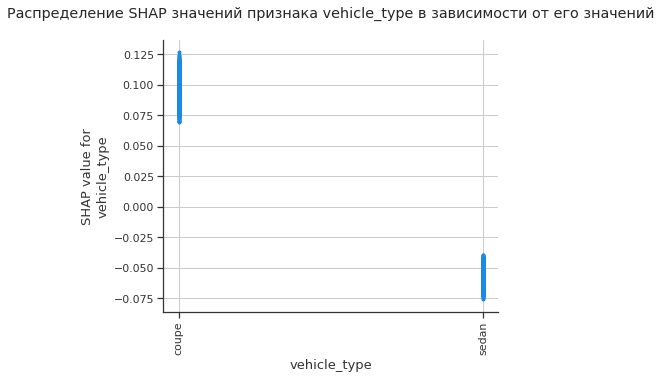

#### Возраст автомобиля

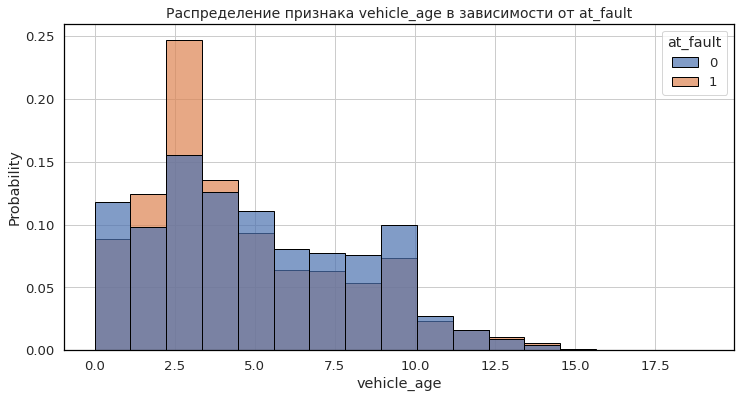
- У автомобилей возрастом 2-3 года есть износ деталей, либо заводской брак, который еще не был обнаружен на осмотре, либо не была проведена вовремя замена деталей
- Отслеживание в системе заказчика пробега и состояния автомобиля. Периодический осмотр и своевременная замена запчастей, предверяя сильный износ
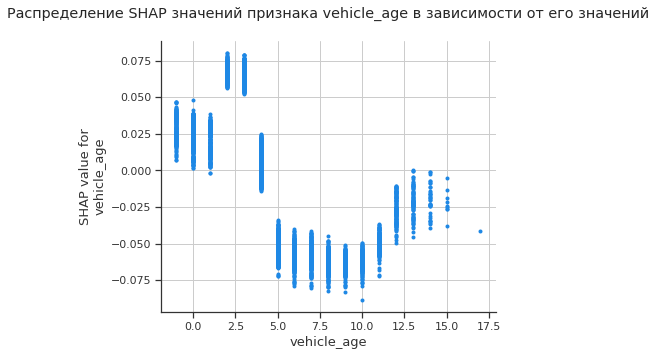

#### Час поездки

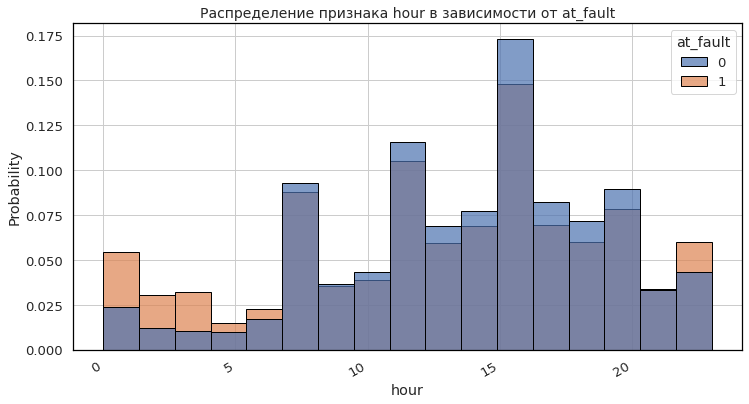
- Хотя общее количество ДТП в ночные часы меньше, тем не менее риск стать виновником ДТП возрастает в это время
- По SHAP-анализу время поездки также оказывает заметное влияние в ночные часы на вероятность ДТП
- Можно делать дополнительное предупреждение в приложении о внимательности в ночное время суток и оставлять принудительно включеный ближний свет у автомобиля
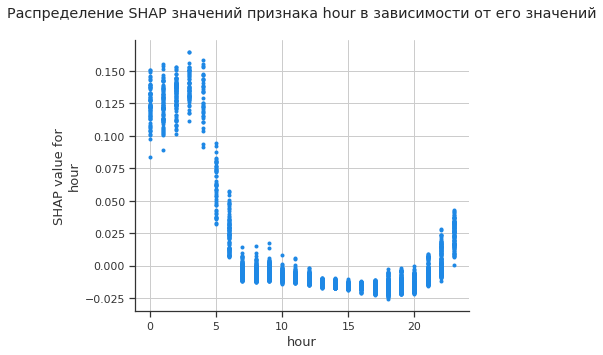

### Вывод

- С использованием Hyperopt было обучено три вида моделей с перебором гиперпараметров. Для сравнения использовалась метрика ROC-AUC 
    - Дерево решений
    - Случайный лес
    - Градиентный бустинг - LGBM


- Лучшая модель по метрике и времени обучения стал `RandomForest` 
    - Гиперпараметры
        - `n_estimators` - 100
        - `criterion` - `gini`
        - `max_depth` - 8
        - `min_samples_leaf` - 65
    - Модель была откалибрована и был выбран порог 0.41 для повышения охвата модели, так как для нас важнее охватить как можно больше вероятных ДТП
    - Метрики модели на тестовой выборке
        - ROC-AUC - 0.661
        - Recall - 0.835
        - Precision - 0.561
    - Наиболее важными признаками для модели являются
        - Тип автомобиля
        - Возраст автомобиля
        - Час поездки
        
        
- По важным признака провели дополнительный анализ и внесли предложения по каждому из них для заказчика
- Возможность создания адекватной модели оценки вероятности ДТП в каршеринге видится средней, по крайней мере с текущими данными от дорожной полиции, так как имеющиеся признаки либо апостериорные посадке в автомобиль, либо по большей части имеют общую рекомендательную значимость для клиента
- Для более адекватной модели оценки риска необходимо больше информации о клиенте
    - Возраст
    - Стаж
    - Категория водительских прав, с учетом типа коробки передач
    - История поездок на каршеринге (типы автомобилей и т.д.)
    - Погодные, географические и дорожные условия возможны при интеграции с системой навигации и информацией на картах
- Они позволят более строго подходить к оценке риска и различным ограничениям на выбор машины в системе

## Общий вывод

В данном проекте на основе данных о ДТП, его участниках и пострадавших объектах от департамента дорожной полиции были исследованы основные факторы влияющие на ДТП и создан первичный вариант модели предсказания его риска. Была оценена возможность дальнейшего развития данного вопроса, выдвинуты гипотезы и предложения по основным факторам ДТП, среди которых можно выделить: трезвость водителя, тип автомобиля, час дня поездки, погодное состояние дороги на маршруте

- **Исходные данные**
    - Три таблицы в базе SQL, которые были выгружены по условиям заказчика
    - Всего 56248 записей
    - Отобранные признаки для обучения модели
    - Пропуски были заполнены в большинстве случаев либо `other`, либо `unknown`

- **Исследовательский анализ отобранных признаков**
    - Целевой признак `at_fault` распределен почти симметрично
        - 50.4 % - виновники
        - 40.6 % - пострадавшие
    - `county_location` - оставили топ-15, остальные убрали в `other`
    - `county_city_location` - оставили топ-50 городов, остальные убрали в `other`
    - `weather_1` - в неясную погоду ДТП происходит немного чаще, чем в ясную
    - `road_surface` - ДТП происходят чуть чаще на не сухом покрытии
    - `weekday` - больше всего ДТП в пятницу, а меньше всего в воскресенье из-за загруженности дорог
    - `hour` - в ночные часы ДТП явно меньше по понятным причинам
    - `lighting` - больше ДТП происходит в темное время суток с и без наличия уличного освещения
    - `party_sobriety` - если водитель в нетрезвом состоянии, то вероятнее он станет виновником ДТП. Есть заметная корреляция с целевым признаком, в будущем, стоит дополнительно рассмотреть это признак для возможного включения в модель
    - `vehicle_type` - если водитель за рулем купе, то вероятность ДТП больше, чем если он будет за рулем седана, так как купе развивает большую скорость и из-за массы может иметь меньшую устойчивость
    - `vehicle_transmission`- ДТП вероятнее на авто с МКПП, чем с АКПП, так как водитель может быть менее опытен в сложных ситуациях для МКПП
    - `vehicle_age` - ДТП вероятнее с авто возрастом 2-3 года, видимо, когда начинается износ деталей, но еще не пройдено ТО
    - `cellphone_in_use` - чуть больше ДТП, если разговаривал за рулем

- **Обучение моделей**
    - С использованием Hyperopt было обучено три вида моделей с перебором гиперпараметров. Для сравнения использовалась метрика ROC-AUC 
        - Дерево решений
        - Случайный лес
        - Градиентный бустинг - LGBM
    - **Лучшая модель** по метрике и времени обучения - `RandomForest` 
        - Гиперпараметры
            - `n_estimators` - 100
            - `criterion` - `gini`
            - `max_depth` - 8
            - `min_samples_leaf` - 65
    - **Метрики модели** на тестовой выборке с порогом 0.41
        - ROC-AUC - 0.661
        - Recall - 0.835
        - Precision - 0.561
        - Охват всех потенциальных ДТП составляет 83.5 %, для чего пришлось пожертвовать точностью определения ДТП - 33.4 %, так как для нас важнее выявить как можно больше потенциальных ДТП, а для 66 % клиентов с менее вероятным ДТП будет по большей части лишь предупреждение, которое можно смахнут на эркане приложения

- **Статистический анализ факторов ДТП**
    - Предложены 9 задач для коллег. Решения некоторых из них:


1. **Количество аварий в зависимости от месяца**
    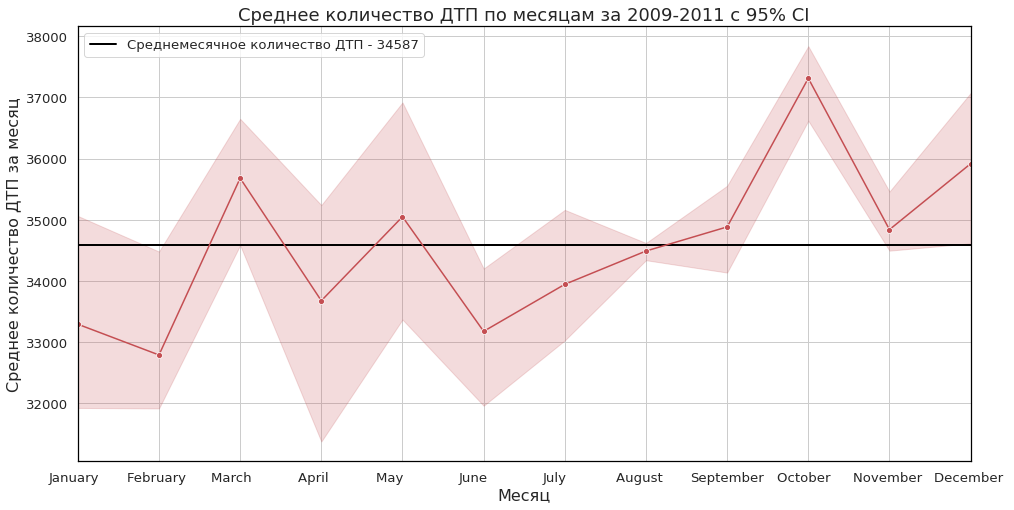
    - Больше всего ДТП за период 2009-середина 2012 года в среднем происходило в 
        - Октябре, Декабре, Мае
        - В 95% CI выше среднемесячных значений лежат 3 последних месяца года - октябрь, ноябрь и декабрь   
    - Меньше всего ДТП за тот же период в среднем происходило в
        - Феврале, Апреле и Январе
    - **Предложение**
        - Можно предложить делать дополнительное предупреждение в такие дни в приложении или инф.окно в главном экране


2. **Влияние типа коробки передач авто на вероятность ДТП**
    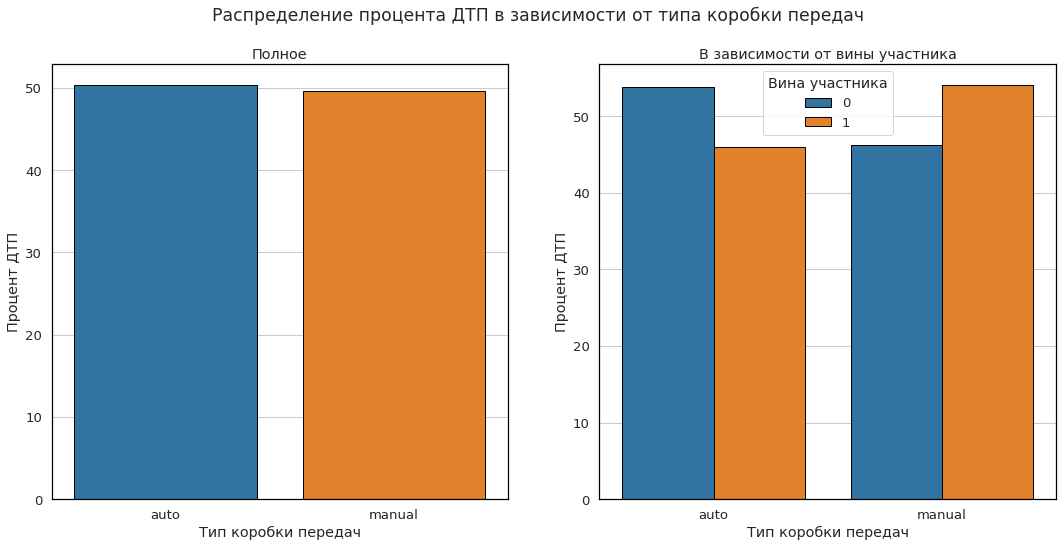
    - В общем случае ДТП не зависят от типа коробки передач у всех участников
    - Среди виновников ДТП чаще происходит с МКПП, чем с АКПП примерно на 10 %
    - Среди пострадавших ДТП - наоборот, чаще с АКПП примерно на 8 %
    - **Предложение**
        - Можно предложить ограничение по водительскому удостоверению клиента на управление МКПП, либо делать дополнительное предупреждение, либо искусственно ограничивать выбор авто в зависимости от стажа


3. **Влияние размера страховки на вероятность ДТП**
    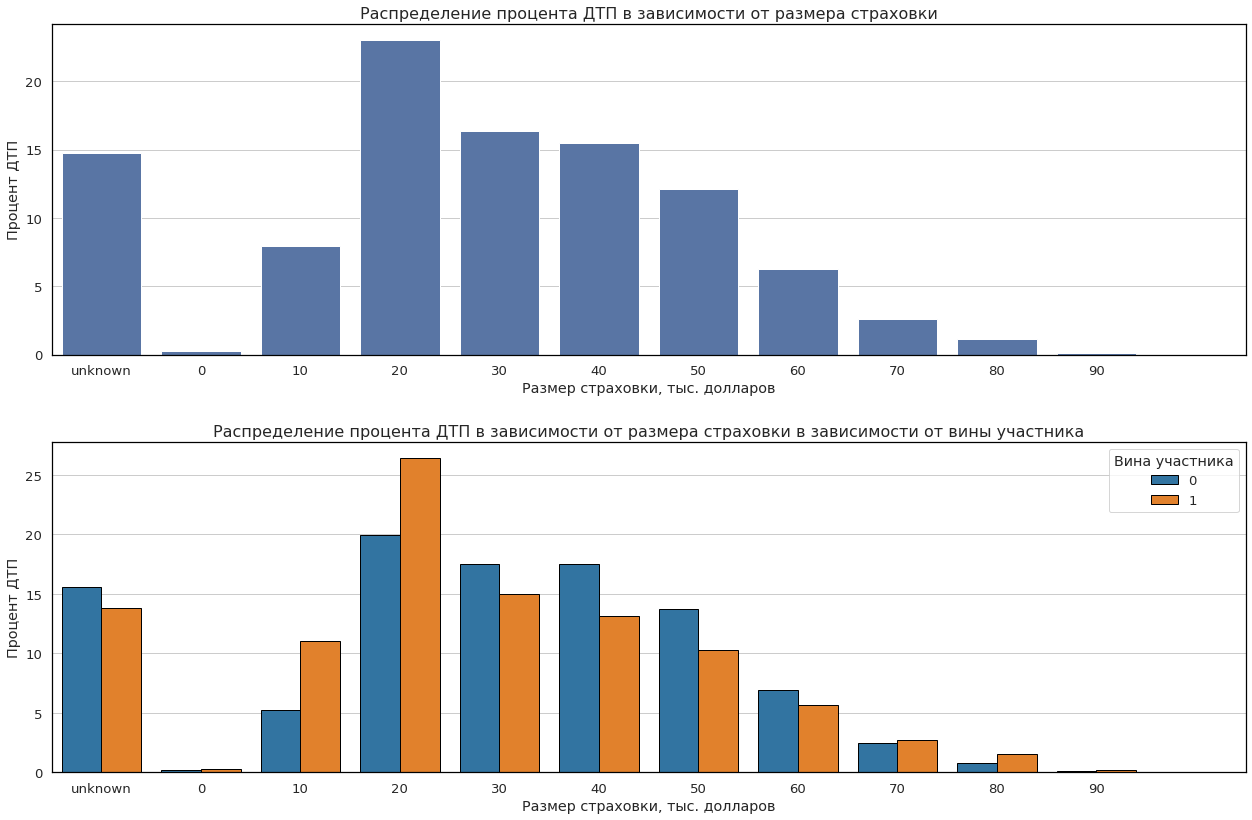
    - В общем случае больше всего ДТП происходит при размере страховки от 20 до 30 тыс. долларов - около 25 % и далее плавно спадает к 90 тыс. долларов
    - Среди виновников ДТП чаще при размере страховки менее 30 тыс. долларов (10-20)
    - **Предложение**
        - Можно предложить обязательную страховку для аккаунта, цена которой варьируется от опыта, чем больше стаж - тем ниже страховка, так получится отсечь небольшую часть неответственных или молодых водителей, у которых риск ДТП выше

- **Анализ важности факторов ДТП по модели**
1. **Тип автомобиля**
    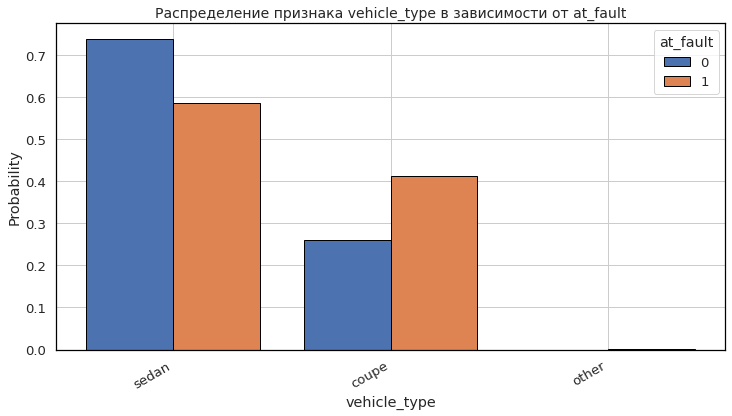
    - Купе с большей вероятностью может попасть в ДТП, чем седан, а так же МКПП чаще, чем АКПП
    - **Предложение**
        - Ограничить выбор автомобилей клиентам в зависимости от стажа и типа водительских прав (АКПП или МКПП)


2. **Возраст автомобиля**
    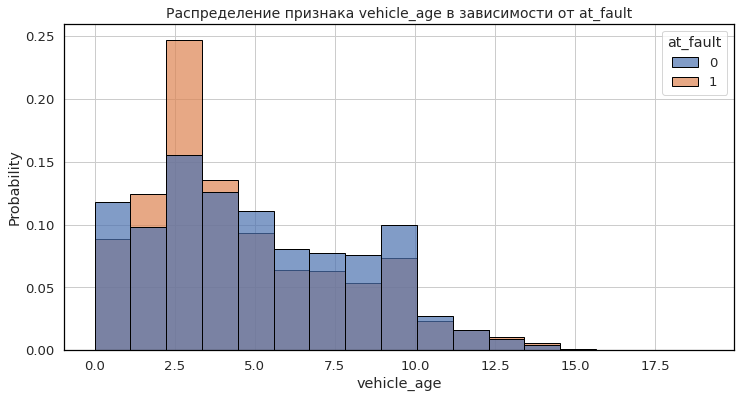
    - У автомобилей возрастом 2-3 года есть износ деталей, либо заводской брак, который еще не был обнаружен на осмотре, либо не была проведена вовремя замена деталей
    - **Предложение**
        - Отслеживание в системе заказчика пробега и состояния автомобиля. Периодический осмотр и своевременная замена запчастей, предверяя сильный износ
        
        
3. **Час поездки**
    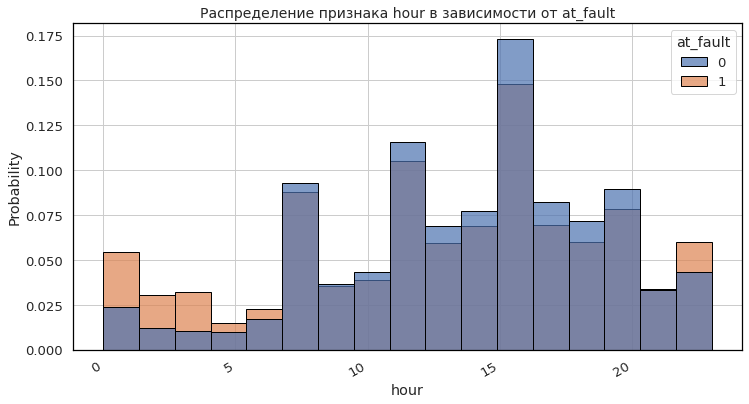
    - Хотя общее количество ДТП в ночные часы меньше, тем не менее риск стать виновником ДТП возрастает в это время, что видно по EDA и анализу влияния признака в модели. Связано с плохим освещением и более рискованным вождением из-за небольшого числа машин, а так же более притупленной реакцией водителя в ночные часы
    - **Предложение**
        - Можно делать дополнительное предупреждение в приложении о внимательности в ночное время суток и оставлять принудительно включеный ближний свет у автомобиля

- **Улучшения модели**
    - Для более адекватной модели оценки риска необходимо больше информации о клиенте
        - Возраст
        - Стаж
        - Категория водительских прав, с учетом типа коробки передач
        - История поездок на каршеринге (типы автомобилей и т.д.)
        - Погодные, географические и дорожные условия возможны при интеграции с системой навигации и информацией на картах
     - Нормальный сервер для ускорения предсказания риска ДТП у клиента

- **Итоговые предложения заказчику**
    - Всплывающее окно-предупреждение о погодных условиях на дороге, загруженном дне недели и времени дня
    - Ограничение выбора автомобиля клиенту в зависимости от стажа и типа водительских прав, включая АКПП и МКПП
    - Отслеживание в системе заказчика пробега и состояния автомобиля. Периодический осмотр и своевременная замена запчастей, предверяя сильный износ
    - Добавить в приложение капчу средней сложности или проверку нейронкой с заранее записанным голосом клиента, где он зачитывает свое ФИО для проверки на трезвость
    - Дополнительно исследовать влияние трезвости водителя на вероятность ДТП и целесообразность и возможность внедрения проверки состояния клиента